# GP and sGP for the exploration of bandgap vs concentration

August 2023

*   GP and sGP developed by [Maxim Ziatdinov](https://scholar.google.com/citations?user=YnSdOoUAAAAJ&hl=en) in [AtomAi](https://atomai.readthedocs.io/en/latest/)

*    Analysis performed by [Yongtao Liu](https://youngtaoliu.wixsite.com/yongtaoliu) and [Sheryl L. Sanchez](https://scholar.google.com/citations?hl=en&user=zFRKT-MAAAAJ)

*   Data by [Mahshid Ahmadi](https://scholar.google.com/citations?hl=en&user=DNOfTQ0AAAAJ&view_op=list_works&sortby=pubdate), Elham Foadian, [Sheryl L. Sanchez](https://scholar.google.com/citations?hl=en&user=zFRKT-MAAAAJ)




In [ ]:
!pip install git+https://github.com/ziatdinovmax/gpax

  Cloning https://github.com/ziatdinovmax/gpax to /tmp/pip-req-build-w34ae9bg
  Running command git clone --filter=blob:none --quiet https://github.com/ziatdinovmax/gpax /tmp/pip-req-build-w34ae9bg
  Resolved https://github.com/ziatdinovmax/gpax to commit b493ba26c0613e6ade694e5bb6847bfbf4511f36
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.3/374.3 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.4/172.4 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 388.0/388.0 kB 29.2 MB/s eta 0:00:00
  Created wheel for gpax: filename=gpax-0.1.9-py3-none-any.whl size=78023 sha256=983e4b88808be187f44246b3c6941d2e63e6cc7c1b1451a812bfac63e2d6c378
  Stored in directory: /tmp/pip-ephem-wheel-cache-0egooo75/wheels/a5/56/fc/8e119a524af7c88b195c4e42839e59919b499e07870028ea70
Successfully built gpax


In [ ]:
!pip install atomai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 kB 25.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.1/266.1 kB 23.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.6/175.6 kB 17.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 27.0 MB/s eta 0:00:00
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl (731.7 MB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl (410.6 MB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl (121.6 MB)
  Using cached nvidia_curand_c

In [ ]:
#Import Modules
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm

import gpax
import jax.random as jra
import jax.numpy as jnp
gpax.utils.enable_x64()
import seaborn as sns
import atomai as aoi
from sklearn.metrics import mean_squared_error

#gdown Installation
!pip install gdown==3.6.0

  Preparing metadata (setup.py) ... done
  Created wheel for gdown: filename=gdown-3.6.0-py3-none-any.whl size=5224 sha256=590f4ab1f00a2f57f90d0f7c478cce2d5ff4b2dce3ea63a0950e3fd626d9ff44
  Stored in directory: /root/.cache/pip/wheels/a7/00/af/7528f0f7a7cd3f085b4b79d81e49744946b654fb19dd979363
Successfully built gdown
  Attempting uninstall: gdown
    Found existing installation: gdown 5.1.0
    Uninstalling gdown-5.1.0:
      Successfully uninstalled gdown-5.1.0


In [ ]:
plt.rcParams["font.size"] = "10"
# plt.rcParams["axes.labelweight"] = "bold"
# plt.rcParams["font.weight"] = "bold"
# plt.rcParams['axes.titleweight']='bold'

In [ ]:
#@title Experimental Data

#Names of Precursors
precursor1 = '$MAPbI_3$' #@param {type:"string"}
precursor2 = '$GAPbBr_3$' #@param {type:"string"}

#Wells that we should ignore
wells_to_ignore = 'A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,B1,B3,B5,B7,B9,B11,B12,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,D1,D3,D5,D7,D9,D11,D12,E1,E2,E3,E4,E5,E6,E7,E8,E9,E10,E11,E12,F1,F3,F5,F7,F9,F11,F12,G1,G2,G3,G4,G5,G6,G7,G8,G9,G10,G11,G12,H1,H2,H3,H4,H5,H6,H7,H8,H9,H10,H11,H12' #@param {type:"string"}

#Information about Measurement Range
start_wavelength = 500 #@param {type:"integer"}
end_wavelength =  850 #@param {type:"integer"}
wavelength_step_size =   1#@param {type:"integer"}

time_step =  5#@param {type:"integer"}

#Information about the reads
number_of_reads = 1 #@param {type:"integer"}
luminescence_read_numbers = '1' #@param {type:"string"}

#Convert the string into a list to use later

if len(wells_to_ignore) !=0:
  wells_to_ignore = list(wells_to_ignore.split(","))
luminescence_read_numbers = list(luminescence_read_numbers.split(","))

In [ ]:
#@title Data Information

#Name of files
data_file_name = 'all compositions.csv' #@param {type:'string'}
composition_file_name = '4-20-23 GAPbBr3 compositions.csv' #@param {type:'string'}

#Download the correct data
data_file = '13hREMYeu-uX3qQEj5YFpRpRs4k4-48NU' #@param {type:"string"}
composition_file = '16sc80Tc0hMhmb2S03MoqYBoJPbmGLUIz' #@param {type:"string"}

In [ ]:
#@title Download Files

!gdown https://drive.google.com/uc?id={data_file}

!gdown https://drive.google.com/uc?id={composition_file}

Downloading...
From: https://drive.google.com/uc?id=13hREMYeu-uX3qQEj5YFpRpRs4k4-48NU
To: /content/all compositions.csv
100% 56.4k/56.4k [00:00<00:00, 69.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=16sc80Tc0hMhmb2S03MoqYBoJPbmGLUIz
To: /content/4-20-23 GAPbBr3 compositions.csv
100% 598/598 [00:00<00:00, 1.81MB/s]


In [ ]:
#@title Into Pandas Dataframes
rawData = pd.read_csv(data_file_name, header=None)
rawData = rawData.replace('OVRFLW', np.NaN)

rawData = rawData.replace(r'^\s*$', np.nan, regex=True) #if blank add this
composition = pd.read_csv(composition_file_name, index_col = 0)


In [ ]:
#@title Parsing the Data into a Dictionary
cells = []

for i in range(1, 9):
  for j in range(1 , 13):
    cells.append(chr(64 + i) + str(j))


for i in wells_to_ignore:
  composition = composition.drop(i, axis = 1)

#First the rows of measurements
rows = []

for i in range(1, number_of_reads + 1):

  rows += rawData[rawData[rawData.columns[0]] == 'Read ' + str(i) + ':EM Spectrum'].index.tolist()

rows += rawData[rawData[rawData.columns[0]] == 'Results'].index.tolist()

#Separate into different dataframes

#First step, make a list of the names
names = []

for i in range(1, number_of_reads + 1):
  names.append('Read ' + str(i))

#Next, make a dictionary
d = {}

for c in names:
  split_name = c.split(' ')
  index = int(split_name[1])
  d[c] = rawData[rows[index - 1] + 2 :rows[index] - 1] #Take a section of the values
  d[c] = d[c].drop([0], axis = 1) #Drop the empty column
  d[c]=d[c].drop([1],axis=1)  # this is to drop the wavelength column only giving the composition values


  new_header = d[c].iloc[0] #grab the first row for the header
  d[c] = d[c][1:] #take the data less the header row
  d[c].columns = new_header #set the header row as the df header
  for i in wells_to_ignore:
    d[c] = d[c].drop(i, axis = 1)
  d[c] = d[c].astype(float) #Make sure that it is composed of numbers


In [ ]:
#@title Convert the Dictionary into a Readable Dataframe

#Convert top luminescence list into an array
luminescence_time = np.array(luminescence_read_numbers)
luminescence_time = [int(i) * time_step for i in luminescence_time]


#Convert wavelength information into an array
luminescence_wavelength = np.arange(start_wavelength,end_wavelength + wavelength_step_size,wavelength_step_size)

#Make a grid
nx, ny = np.meshgrid(luminescence_wavelength, luminescence_time)

#Load information into a dataframe
luminescence_df = pd.DataFrame()

for i in luminescence_read_numbers:
   temp_df = d['Read ' + str(i)]
    # Assuming temp_df needs to be modified or used as is
   luminescence_df = pd.concat([luminescence_df, temp_df], ignore_index=True)



luminescence_df = luminescence_df.fillna(0.0)

luminescence_vec = np.array(luminescence_df)

In [ ]:
compositions = composition.values.T
targets = d['Read 1'].values.T

luminescence_wavelength = np.arange(
    start_wavelength,end_wavelength + wavelength_step_size, wavelength_step_size)

print(compositions.shape, targets.shape, luminescence_wavelength.shape)

(15, 2) (15, 351) (351,)


<Axes: >

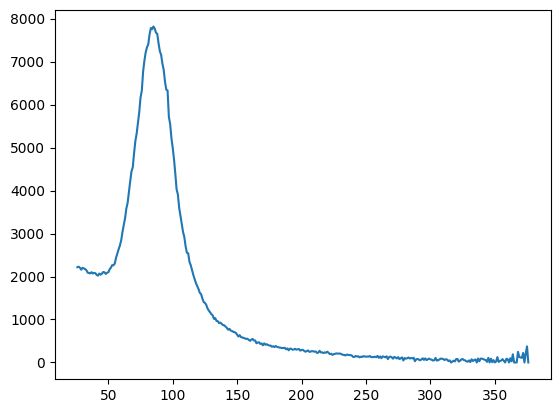

In [ ]:
d['Read 1']['F10'].plot()

603 16503.0


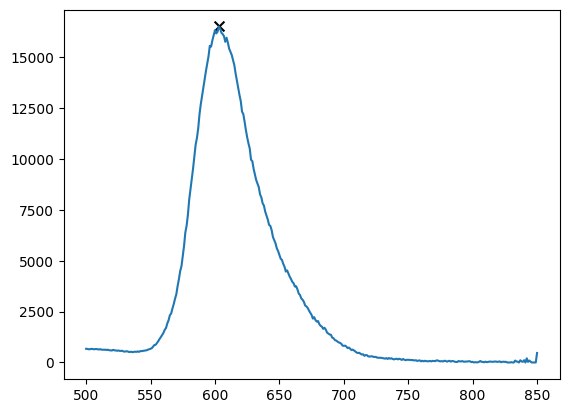

In [ ]:


k = 12
# Plot the data
plt.plot(luminescence_wavelength, targets[k])

# Manually identify the peak location
peak_pos = np.argmax(targets[k])
peak_int = targets[k][peak_pos]

# Plot the peak
plt.scatter(luminescence_wavelength[peak_pos], peak_int, marker='x', s=50, c='k')

# Print the peak position and intensity
print(luminescence_wavelength[peak_pos], peak_int)


In [ ]:
peaks_all, compositions_all = [], []

for i, t in enumerate(targets):
    # Manually identify the peak location
    peak_pos = np.argmax(t)
    peak_int = t[peak_pos]

    # Add the peak position and composition to the list
    peaks_all.append(peak_pos)
    compositions_all.append(compositions[i])

compositions_all = np.array(compositions_all)
peaks_all = np.array(peaks_all)
peaks_all = luminescence_wavelength[peaks_all]

print(compositions_all.shape, peaks_all.shape)


(15, 2) (15,)


In [ ]:
compositions_all

array([[  0., 100.],
       [  2.,  98.],
       [  4.,  96.],
       [  6.,  94.],
       [  8.,  92.],
       [ 10.,  90.],
       [ 12.,  88.],
       [ nan,  nan],
       [ nan,  nan],
       [ nan,  nan],
       [ 40.,  60.],
       [ 50.,  50.],
       [ 60.,  40.],
       [ 70.,  30.],
       [ 80.,  20.]])

In [ ]:
peaks_all, compositions_all = [], []

for i, t in enumerate(targets):
    # Manually identify the peak location
    peak_pos = np.argmax(t)
    peak_int = t[peak_pos]

    # Add the peak position and composition to the list
    peaks_all.append(peak_pos)
    compositions_all.append(compositions[i])

compositions_all = np.array(compositions_all)
peaks_all = np.array(peaks_all)
peaks_all = luminescence_wavelength[peaks_all]

print(compositions_all.shape, peaks_all.shape)


(15, 2) (15,)


In [ ]:
bandgap=1240/peaks_all[:]
print(bandgap)

[1.60413972 1.61879896 1.61038961 1.62516383 1.63588391 1.64674635
 1.65997323 1.6734143  1.7032967  1.78932179 1.85351271 1.92546584
 2.05638474 2.15277778 2.21824687]


Text(0, 0.5, 'Peak Position (nm)')

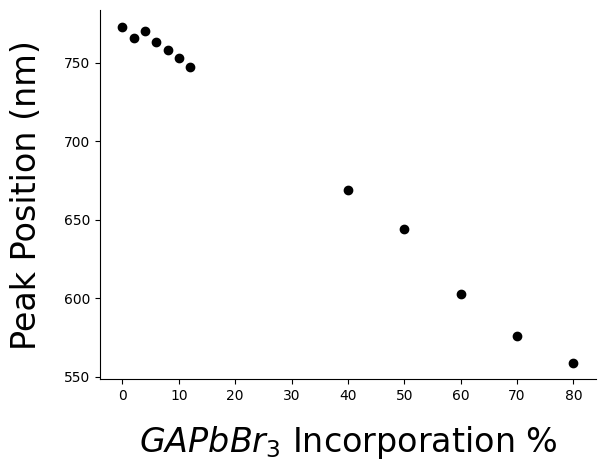

In [ ]:
plt.scatter(compositions_all[:, 0], peaks_all, color='black')
sns.despine()
plt.xlabel('$GAPbBr_3$ Incorporation %', labelpad=15,size=24)
plt.ylabel('Peak Position (nm)', labelpad=15,size=24)

In [ ]:
# Create a 2D array by horizontally stacking X and y
data = np.hstack((compositions_all[:,0].reshape(-1, 1), bandgap.reshape(-1, 1)))

# Save the data to a CSV file
np.savetxt('bandgap info.csv', data, delimiter=',', header='composition,bandgap', comments='')

In [ ]:
# Read initial data
df_initial = pd.read_csv('bandgap info.csv')



# Default sGP

In [ ]:
df_initial.iloc[[0,14],[0,1]]


,composition,bandgap
0,0.0,1.604140
14,80.0,2.218247


In [ ]:
import numpyro
from typing import Dict

# Linear function
def linear(x, params):
    """Linear mean function"""
    return params["a"] * x + params["b"]

# Priors over the linear function
def linear_prior():
    """Priors over linear coefficients"""
    a = numpyro.sample("a", numpyro.distributions.LogNormal(0, 1))
    b = numpyro.sample("b", numpyro.distributions.Uniform(1, 3))
    return {"a": a, "b": b}

# Piecewise linear function
def piecewise(x: jnp.ndarray, params: Dict[str, float]) -> jnp.ndarray:
    """Piecewise linear function"""
    return jnp.piecewise(
        x, [x < params["t"], x >= params["t"]],
        [lambda x: params["a1"] * x + params["b1"],
         lambda x: params["a2"] * x + params["b2"]])

# Priors over the picewise function
def piecewise_prior():
    """Priors over coefficients"""
    a1 = numpyro.sample("a1", numpyro.distributions.LogNormal(0, 1))
    b1 = numpyro.sample("b1", numpyro.distributions.Normal(1, 3))
    a2 = numpyro.sample("a2", numpyro.distributions.LogNormal(0, 1))
    b2 = numpyro.sample("b2", numpyro.distributions.Normal(1, 3))
    t = numpyro.sample("t", numpyro.distributions.Uniform(10, 100))
    return {"a1": a1, "b1": b1, "a2": a2, "b2": b2, "t": t}

# Quadratic function
def quadratic(x, params):
    """Quadratic function"""
    return params["a"] * x**2 + params["b"] * x + params["c"]

# Priors over the quadratic function
def quadratic_prior():
    """Priors over coefficients"""
    a = numpyro.sample("a", numpyro.distributions.LogNormal(0, 1))
    b = numpyro.sample("b", numpyro.distributions.Normal(1, 3))
    c = numpyro.sample("c", numpyro.distributions.Normal(1, 3))
    return {"a": a, "b": b, "c": c}

In [ ]:
noise_prior = lambda: numpyro.sample("noise", numpyro.distributions.HalfNormal(0.01))

### Default sGP functions

## Linear mean function

In [ ]:
all_uncertainty_linear = []
df_linear=pd.DataFrame(columns=['composition','bandgap'])
df_linear=pd.concat([df_initial.iloc[[0,14],[0,1]],
df_linear])


###Only run new data if adding in new data!

In [ ]:
# input new data as dictionary
new_data = {'composition': 65, 'bandgap':2.119658}

# append new data to dataframe
df_linear = df_linear.append(new_data, ignore_index=True)


<ipython-input-172-7a2bbf45fa0f>:5: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_linear = df_linear.append(new_data, ignore_index=True)


In [ ]:


# convert dataframe to numpy array
X_linear = df_linear['composition'].values
y_linear = df_linear['bandgap'].values

# print updated numpy arrays
print(X_linear)
print(y_linear)




[ 0. 80. 98. 88. 75. 55. 25.  8. 92. 36. 15. 65.]
[1.60413972 2.21824687 2.33521657 2.26277372 2.202487   2.056385
 1.789322   1.63588391 2.2962963  1.8128655  1.666667   2.119658  ]


In [ ]:

# Get random number generator keys
rng_key, rng_key_predict = gpax.utils.get_keys()
# initialize structured GP model
sgp_model = gpax.ExactGP(1, kernel='Matern',
                         mean_fn=linear, mean_fn_prior=linear_prior, kernel_prior=None,noise_prior=noise_prior)
# Run MCMC to obtain posterior samples
sgp_model.fit(rng_key, X_linear, y_linear, jitter=1e-4)

# Generate denser grid for prediction
X_new = jnp.linspace(0, 98, 200)[:, None]
X_new = jnp.delete(X_new, np.where(X_new==X_linear)[0], axis=0)
# Make a prediction
y_mean, y_samples = sgp_model.predict_in_batches(rng_key_predict, X_new, noiseless=True, jitter=1e-4)


/usr/local/lib/python3.10/dist-packages/gpax/models/gp.py:106: FutureWarning: `noise_prior` is deprecated and will be removed in a future version. Please use `noise_prior_dist` instead, which accepts an instance of a numpyro.distributions Distribution object, e.g., `dist.HalfNormal(scale=0.1)`, rather than a function that calls `numpyro.sample`.
  warnings.warn("`noise_prior` is deprecated and will be removed in a future version. "
sample: 100%|██████████| 4000/4000 [00:07<00:00, 524.14it/s, 7 steps of size 3.70e-01. acc. prob=0.90]  



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
          a      0.01      0.01      0.01      0.01      0.02    769.13      1.00
          b      1.53      0.38      1.47      1.00      2.03   1062.50      1.00
k_length[0]     72.52     37.15     65.85     19.76    125.70   1003.54      1.00
    k_scale      0.52      0.70      0.29      0.01      1.20    837.94      1.00
      noise      0.00      0.00      0.00      0.00      0.00    950.81      1.00



In [ ]:
# Compute uncertainty
obj = gpax.acquisition.UE(
        rng_key_predict, sgp_model, X_new, noiseless=False, jitter=1e-4)
next_point = obj.argmax()
X_next1 = X_new[next_point]


print(X_next1)

[44.81407035]


[44.81407035]


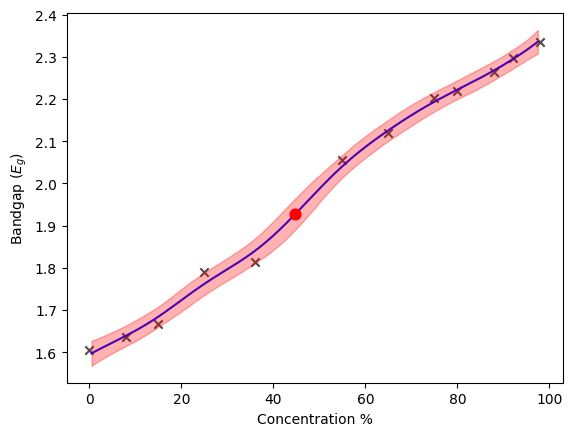

In [ ]:
_, ax = plt.subplots(dpi=100)
ax.set_xlabel("Concentration %")
ax.set_ylabel("Bandgap ($E_g$)")
ax.scatter(X_linear, y_linear, marker='x', c='k', zorder=1, alpha=0.7)
ax.plot(X_new, y_mean, lw=1.5, zorder=1, c='b')
ax.fill_between(X_new.squeeze(), y_mean - y_samples.std(axis=(0,1)), y_mean + y_samples.std(axis=(0,1)),
                color='r', alpha=0.3)

ax.scatter(X_next1, y_mean[next_point], s=60, c='r')

#ax.legend(loc='upper left',fontsize=10)

print(X_next1)




In [ ]:
# add the uncertainty of this step to the list
this_uncertainty = y_samples.std(axis=(0,1)).sum()
all_uncertainty_linear.append(this_uncertainty)


In [ ]:
all_uncertainty_linear

[Array(260.0538491, dtype=float64),
 Array(182.78069284, dtype=float64),
 Array(127.3394993, dtype=float64),
 Array(98.01464656, dtype=float64),
 Array(73.48028806, dtype=float64),
 Array(46.25840575, dtype=float64),
 Array(11.12742435, dtype=float64),
 Array(14.11950151, dtype=float64),
 Array(6.52387773, dtype=float64),
 Array(5.24974203, dtype=float64)]

## With piecewise mean function:

In [ ]:
all_uncertainty_piecewise3 = []

In [ ]:
df_piecewise=pd.DataFrame(columns=['composition','bandgap'])

df_piecewise=pd.concat ([df_initial.iloc[[0,14],[0,1]],df_piecewise])




###Only run this if adding new compositions!!

In [ ]:
import pandas as pd

# Existing DataFrame or create an empty one
data = {'composition': [0.0, 80.0],
        'bandgap': [1.60414, 2.218247]}
df_piecewise = pd.DataFrame(data)

# New data to append
new_data_p = {'composition': [ 98],
              'bandgap': [2.33521657]}

# Append new data to the DataFrame
df_piecewise = df_piecewise.append(pd.DataFrame(new_data_p), ignore_index=True)

print(df_piecewise)


   composition   bandgap
0          0.0  1.604140
1         80.0  2.218247
2         98.0  2.335217


<ipython-input-181-bd80848c712c>:13: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_piecewise = df_piecewise.append(pd.DataFrame(new_data_p), ignore_index=True)


In [ ]:
# New data to append
new_data_p = {'composition': [70],
              'bandgap': [2.15277778]}

# Append new data to the DataFrame
df_piecewise = df_piecewise.append(pd.DataFrame(new_data_p), ignore_index=True)

print(df_piecewise)

    composition   bandgap
0           0.0  1.604140
1          80.0  2.218247
2          98.0  2.335217
3          55.0  2.056385
4          36.0  1.812865
5          35.0  1.853513
6          27.0  1.758865
7          14.0  1.673414
8          10.0  1.646746
9          95.0  2.344045
10         88.0  2.262774
11         70.0  2.152778


<ipython-input-244-886f95a973cd>:6: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_piecewise = df_piecewise.append(pd.DataFrame(new_data_p), ignore_index=True)


In [ ]:
# convert dataframe to numpy array
X_piecewise = df_piecewise['composition'].values
y_piecewise = df_piecewise['bandgap'].values


# print updated numpy arrays
print(X_piecewise)
print(y_piecewise)


[ 0. 80. 98. 55. 36. 35. 27. 14. 10. 95. 88. 70.]
[1.60414    2.218247   2.33521657 2.056385   1.8128655  1.853513
 1.75886525 1.6734143  1.64674635 2.344045   2.26277372 2.15277778]


In [ ]:
# Get random number generator keys
rng_key, rng_key_predict = gpax.utils.get_keys()
# initialize structured GP model
sgp_model = gpax.ExactGP(1, kernel='Matern',
                         mean_fn=piecewise, mean_fn_prior=piecewise_prior)
# Run MCMC to obtain posterior samples
sgp_model.fit(rng_key, X_piecewise,y_piecewise,jitter=1e-4)

# Generate denser grid for prediction
X_new = jnp.linspace(0, 98, 200)[:, None]
X_new = jnp.delete(X_new, np.where(X_new==X_piecewise)[0], axis=0)
# Make a prediction
y_mean, y_samples = sgp_model.predict_in_batches(rng_key_predict, X_new, noiseless=True)

sample: 100%|██████████| 4000/4000 [00:18<00:00, 220.46it/s, 14 steps of size 6.74e-02. acc. prob=0.89] 



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
         a1      0.02      0.01      0.02      0.01      0.03    101.68      1.00
         a2      1.70      1.95      1.05      0.03      3.79    303.20      1.01
         b1      1.12      0.42      1.19      0.44      1.72    125.76      1.01
         b2      0.73      3.04      0.81     -4.64      5.43    209.21      1.01
k_length[0]     16.60     23.61      4.43      0.02     48.95     78.97      1.00
    k_scale      0.36      0.69      0.19      0.01      0.69    121.88      1.00
      noise      0.12      0.15      0.07      0.00      0.25    135.63      1.02
          t     98.97      0.55     98.96     98.09     99.82    139.49      1.02



In [ ]:

# Compute uncertainty
obj = gpax.acquisition.UE(
        rng_key_predict, sgp_model, X_new, noiseless=False, jitter=1e-4)
next_point = obj.argmax()
X_next2 = X_new[next_point]


print(X_next2)

[2.95477387]


[2.95477387]


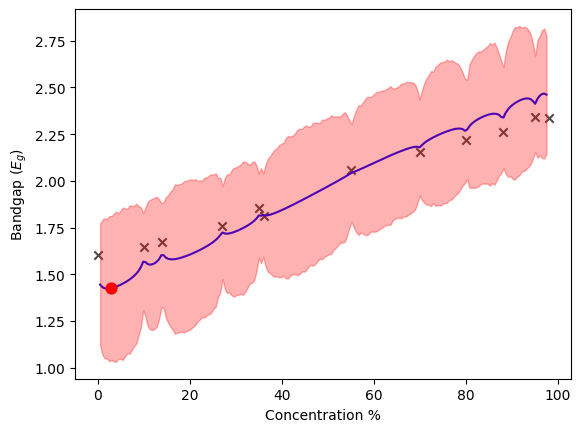

In [ ]:
_, ax = plt.subplots(dpi=100)
ax.set_xlabel("Concentration %")
ax.set_ylabel("Bandgap ($E_g$)")
ax.scatter(X_piecewise, y_piecewise, marker='x', c='k', zorder=1, label="Noisy observations", alpha=0.7)
ax.plot(X_new, y_mean, lw=1.5, zorder=1, c='b', label='Posterior mean')
ax.fill_between(X_new.squeeze(), y_mean - y_samples.std(axis=(0,1)), y_mean + y_samples.std(axis=(0,1)),
                color='r', alpha=0.3, label="Model uncertainty")

ax.scatter(X_next2, y_mean[next_point], s=60, c='r', label='Next point to measure')
#ax.legend(loc='upper left',fontsize=10)


print(X_next2)

In [ ]:
 # add the uncertainty of this step to the list
this_uncertainty_p = y_samples.std(axis=(0,1)).sum()
all_uncertainty_piecewise3.append(this_uncertainty_p)

In [ ]:
all_uncertainty_piecewise3

[Array(9074.25756592, dtype=float64),
 Array(4530.33204554, dtype=float64),
 Array(3693.87284933, dtype=float64),
 Array(1831.90661386, dtype=float64),
 Array(947.43347606, dtype=float64),
 Array(227.20291622, dtype=float64),
 Array(145.45076209, dtype=float64),
 Array(106.12619261, dtype=float64),
 Array(97.85804033, dtype=float64),
 Array(69.38492085, dtype=float64)]

## Quadratic mean function

In [ ]:
all_uncertainty_quad = []

In [ ]:
df_quadratic=pd.DataFrame(columns=['composition','bandgap'])

df_quadratic=pd.concat ([df_initial.iloc[[0,14],[0,1]],df_quadratic])


In [ ]:
# input new data as dictionary
new_data_q = {'composition': 88, 'bandgap': 2.26277372263}

# append new data to dataframe
df_quadratic = df_quadratic.append(new_data_q, ignore_index=True)


<ipython-input-317-d7a71253ae58>:5: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_quadratic = df_quadratic.append(new_data_q, ignore_index=True)


In [ ]:



# convert dataframe to numpy array
X_quadratic = df_quadratic['composition'].values
y_quadratic = df_quadratic['bandgap'].values

# print updated numpy arrays
print(X_quadratic)
print(y_quadratic)




[ 0. 80. 98. 40. 48. 95. 25. 50. 65.  8. 55. 88.]
[1.60413972 2.21824687 2.33521657 1.85351271 1.96202532 2.344045
 1.789322   1.968254   2.119658   1.63588391 2.056385   2.26277372]


In [ ]:

# Get random number generator keys
rng_key, rng_key_predict = gpax.utils.get_keys()
# initialize structured GP model
sgp_model = gpax.ExactGP(1, kernel='Matern',
                         mean_fn=quadratic, mean_fn_prior=quadratic_prior)
# Run MCMC to obtain posterior samples
sgp_model.fit(rng_key, X_quadratic, y_quadratic,jitter=1e-4)
# Generate denser grid for prediction
X_new = jnp.linspace(0, 98, 200)[:, None]
X_new = jnp.delete(X_new, np.where(X_new==X_quadratic)[0], axis=0)
# Make a prediction
y_mean, y_samples = sgp_model.predict_in_batches(rng_key_predict, X_new, noiseless=True)


sample: 100%|██████████| 4000/4000 [00:10<00:00, 371.83it/s, 31 steps of size 1.11e-01. acc. prob=0.87]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
          a      0.00      0.00      0.00      0.00      0.00    230.47      1.00
          b     -0.11      0.06     -0.09     -0.19     -0.02    248.64      1.00
          c      2.55      1.27      2.56      0.73      4.71    794.61      1.00
k_length[0]     18.97     14.40     18.00      0.10     38.19    316.57      1.00
    k_scale      2.07      2.79      1.24      0.05      4.78    383.02      1.00
      noise      0.28      0.40      0.15      0.01      0.64    413.55      1.00



In [ ]:

# Compute uncertainty
obj = gpax.acquisition.UE(
        rng_key_predict, sgp_model, X_new, noiseless=False, jitter=1e-4)
next_point = obj.argmax()
X_next3 = X_new[next_point]


print(X_next3)

[71.40703518]


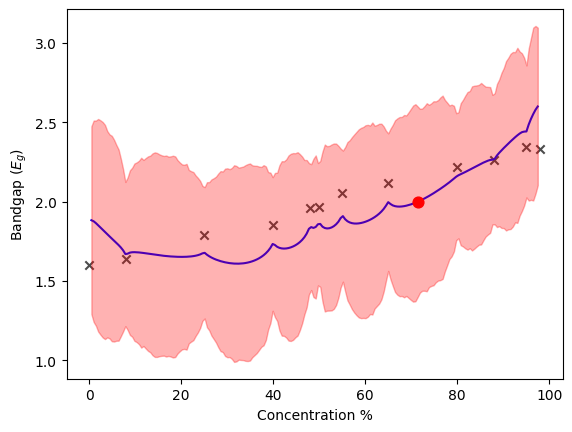

In [ ]:
_, ax = plt.subplots(dpi=100)
ax.set_xlabel("Concentration %")
ax.set_ylabel("Bandgap ($E_g$)")
ax.scatter(X_quadratic, y_quadratic, marker='x', c='k', zorder=1, label="Noisy observations", alpha=0.7)
ax.plot(X_new, y_mean, lw=1.5, zorder=1, c='b', label='Posterior mean')
ax.fill_between(X_new.squeeze(), y_mean - y_samples.std(axis=(0,1)), y_mean + y_samples.std(axis=(0,1)),
                color='r', alpha=0.3, label="Model uncertainty")

ax.scatter(X_next3, y_mean[next_point], s=60, c='r', label='Next point to measure')
#ax.legend(loc='upper left',fontsize=10)


In [ ]:

 # add the uncertainty of this step to the list
this_uncertainty_q = y_samples.std(axis=(0,1)).sum()
all_uncertainty_quad.append(this_uncertainty_q)

In [ ]:
all_uncertainty_quad

[Array(983.96520294, dtype=float64),
 Array(581.04654752, dtype=float64),
 Array(476.74128792, dtype=float64),
 Array(395.46753985, dtype=float64),
 Array(333.17231481, dtype=float64),
 Array(281.98971549, dtype=float64),
 Array(235.83593137, dtype=float64),
 Array(198.74280635, dtype=float64),
 Array(146.86715358, dtype=float64),
 Array(107.64419167, dtype=float64)]

## Customized function for sGP

In [ ]:
from typing import Dict
from jax import numpy as jnp

def c_sGP(x: jnp.ndarray, params: Dict[str, float]) -> jnp.ndarray:
    b = params.get('b', 2)  # Default bowing factor

    # Initiate the list to store terms of each model
    model_terms = []

    # Model 1: Linear
    if "w1" in params:
        model_terms.append(params["w1"] * (params.get("a1", 0) * x + params.get("b1", 0) * (1 - x)))

    # Model 2: Bowing
    if "w2" in params:
        model_terms.append(params["w2"] * (params.get("a2", 0) * x + params.get("b2", 0) * (1 - x) - b * (1 - x) * x))

    # Model 3: No alloy formation at a certain composition
    if "w3" in params:
        model_terms.append(params["w3"] * (params.get("a3", 0) * x + params.get("b3", 0) * (1 - x)))

    # Model 4: No alloy formation at two certain compositions
    if "w4" in params:
        model_terms.append(params["w4"] * (params.get("a4", 0) * x + params.get("b4", 0) * (1 - x)))

    # Model 5: No alloy formation at a certain composition with bowing model
    if "w5" in params:
        model_terms.append(params["w5"] * (params.get("a5", 0) * x + params.get("b5", 0) * (1 - x) - b * (1 - x) * x))

    # Combine all the terms
    combined_term = sum(model_terms)

    return jnp.array([combined_term])


#import numpyro

def c_sGP_prior():
    # Coefficients for the different models
    coeffs = ["a", "b"]
    params = {}
    for i in range(1, 6):
        for coeff in coeffs:
            key = f"{coeff}{i}"
            params[key] = numpyro.sample(key, numpyro.distributions.Normal(2, 0.5))

    # Bowing factor
    params["b"] = numpyro.sample("b", numpyro.distributions.Normal(2, 0.5))

    # Mixing coefficients for the models
    weights = numpyro.sample("weights", numpyro.distributions.Dirichlet(jnp.ones(5)))

    # Assign weights
    for i, w in enumerate(["w1", "w2", "w3", "w4", "w5"]):
        params[w] = weights[i]

    return params




### Customized function for sGP

In [ ]:
all_uncertainty_custom = []


In [ ]:
df_custom=pd.DataFrame(columns=['composition','bandgap'])
df_custom=pd.concat([df_initial.iloc[[0,14],[0,1]],
df_custom])


In [ ]:
# input new data as dictionary
new_data = {'composition': [], 'bandgap':2.33521657}

# append new data to dataframe
df_custom = df_custom.append(new_data, ignore_index=True)


<ipython-input-458-0dbca94ce1cc>:5: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_custom = df_custom.append(new_data, ignore_index=True)


In [ ]:


# convert dataframe to numpy array
X_custom = df_custom['composition'].values
y_custom = df_custom['bandgap'].values

# print updated numpy arrays
print(X_custom)
print(y_custom)




[ 0. 80. 98.]
[1.60413972 2.21824687 2.33521657]


In [ ]:
uncertainty_dict


{60.0: Array(185.90944271, dtype=float64),
 55.0: Array(270.73069051, dtype=float64),
 95.0: Array(180.21028135, dtype=float64),
 92.0: Array(168.56616624, dtype=float64),
 85.0: Array(172.75641852, dtype=float64),
 75.0: Array(160.14685672, dtype=float64),
 30.0: Array(101.09483702, dtype=float64),
 14.0: Array(35.88614518, dtype=float64),
 43.0: Array(10.52211897, dtype=float64),
 20.0: Array(6.6722457, dtype=float64),
 65.0: Array(6.07098324, dtype=float64),
 0.5: Array(4.76618321, dtype=float64),
 35: Array(4.19968015, dtype=float64),
 10: Array(4.01282258, dtype=float64),
 45: Array(3.7096403, dtype=float64),
 80: Array(3.48901256, dtype=float64),
 2: Array(3.36791931, dtype=float64),
 25: Array(3.24342632, dtype=float64),
 70: Array(3.29651443, dtype=float64),
 40: Array(3.1627136, dtype=float64),
 83: Array(3.1440973, dtype=float64),
 27: Array(3.11029516, dtype=float64),
 50: Array(3.08835272, dtype=float64),
 5: Array(3.65254171, dtype=float64),
 90: Array(3.59298223, dtype=fl

In [ ]:

# Get random number generator keys
rng_key, rng_key_predict = gpax.utils.get_keys()
# initialize structured GP model
sgp_model = gpax.ExactGP(1, kernel='Matern',
                         mean_fn=c_sGP, mean_fn_prior=c_sGP_prior, kernel_prior=None,noise_prior=noise_prior)
# Run MCMC to obtain posterior samples
sgp_model.fit(rng_key, X_custom, y_custom, jitter=1e-4)

# Generate denser grid for prediction
X_new = jnp.linspace(0, 98, 200)[:, None]
X_new = jnp.delete(X_new, np.where(X_new==X_custom)[0], axis=0)
# Make a prediction
y_mean, y_samples = sgp_model.predict_in_batches(rng_key_predict, X_new, noiseless=True, jitter=1e-4)


/usr/local/lib/python3.10/dist-packages/gpax/models/gp.py:106: FutureWarning: `noise_prior` is deprecated and will be removed in a future version. Please use `noise_prior_dist` instead, which accepts an instance of a numpyro.distributions Distribution object, e.g., `dist.HalfNormal(scale=0.1)`, rather than a function that calls `numpyro.sample`.
  warnings.warn("`noise_prior` is deprecated and will be removed in a future version. "
sample: 100%|██████████| 4000/4000 [00:21<00:00, 183.25it/s, 767 steps of size 6.04e-03. acc. prob=0.97]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
         a1      1.94      0.43      1.95      1.21      2.61   1000.88      1.00
         a2      2.00      0.49      1.99      1.24      2.86   2089.81      1.00
         a3      1.95      0.44      1.95      1.24      2.68   1736.07      1.00
         a4      1.95      0.46      1.95      1.23      2.72   1207.78      1.00
         a5      1.99      0.52      1.99      1.10      2.81   1652.91      1.00
          b      1.56      0.69      1.61      0.47      2.80    420.88      1.00
         b1      2.01      0.47      2.02      1.29      2.83   1196.40      1.00
         b2      2.00      0.52      1.99      1.23      2.90   1550.91      1.00
         b3      2.03      0.43      2.03      1.31      2.73   1652.41      1.00
         b4      2.03      0.44      2.02      1.28      2.74   1242.31      1.00
         b5      2.01      0.53      2.01      1.19      2.94   1222.59      1.00
k_length[0]    

In [ ]:
# Compute uncertainty
obj = gpax.acquisition.UE(
        rng_key_predict, sgp_model, X_new, noiseless=False, jitter=1e-4)
next_point = obj.argmax()
X_next1 = X_new[next_point]


print(X_next1)

[93.5678392]


[93.5678392]


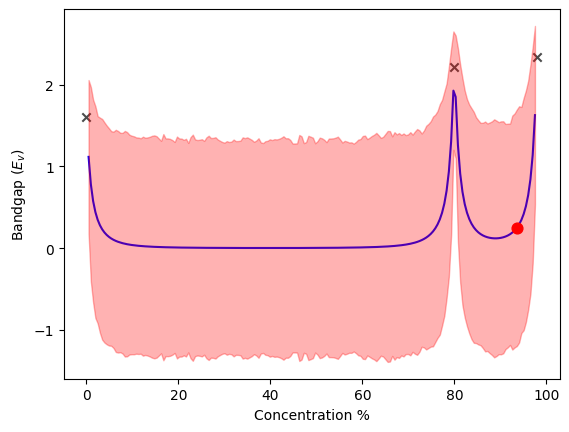

In [ ]:
_, ax = plt.subplots(dpi=100)
ax.set_xlabel("Concentration %")
ax.set_ylabel("Bandgap ($E_v$)")
ax.scatter(X_custom, y_custom, marker='x', c='k', zorder=1, alpha=0.7)
ax.plot(X_new, y_mean, lw=1.5, zorder=1, c='b')
ax.fill_between(X_new.squeeze(), y_mean - y_samples.std(axis=(0,1)), y_mean + y_samples.std(axis=(0,1)),
                color='r', alpha=0.3)

ax.scatter(X_next1, y_mean[next_point], s=60, c='r')

#ax.legend(loc='upper left',fontsize=10)

print(X_next1)




In [ ]:
# add the uncertainty of this step to the list
this_uncertainty = y_samples.std(axis=(0,1)).sum()
all_uncertainty_custom.append(this_uncertainty)


In [ ]:
all_uncertainty_custom

[Array(263.97395966, dtype=float64)]

#Automatic Iteration

In [ ]:
from gpax import acquisition
# Given data
compositions = [0, 0.5, 2, 4, 5, 6, 8, 10, 12, 14, 15, 20, 25, 27, 30, 35, 36, 40, 43, 45, 48, 50, 55, 60, 65, 70, 75, 80, 83, 85, 88, 90, 92, 95, 98]
bandgaps = [1.60413972, 1.60413972,1.61879896, 1.61038961, 1.61038961, 1.62516383, 1.63588391, 1.64674635, 1.65997323, 1.6734143, 1.666666667, 1.7032967, 1.789321789, 1.75886525, 1.78932179, 1.853512706, 1.812865497, 1.85351271, 1.861861862, 1.919504644, 1.962025316, 2.056384743,2.056384743, 2.05638474, 2.11965812, 2.15277778, 2.202486679, 2.21824687, 2.210338681, 2.271062271, 2.262773723, 2.28782288, 2.296296296, 2.344045369, 2.33521657]

# Initialize with 0 and 98
X_init = np.array([[0], [98]])
y_init = np.array([bandgaps[0], bandgaps[-1]])
uncertainty_dict = {}

/usr/local/lib/python3.10/dist-packages/gpax/models/gp.py:109: FutureWarning: `noise_prior` is deprecated and will be removed in a future version. Please use `noise_prior_dist` instead, which accepts an instance of a numpyro.distributions Distribution object, e.g., `dist.HalfNormal(scale=0.1)`, rather than a function that calls `numpyro.sample`.
  warnings.warn(
sample: 100%|██████████| 4000/4000 [00:18<00:00, 221.85it/s, 511 steps of size 6.73e-03. acc. prob=0.89]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
         a1      1.77      0.48      1.76      1.03      2.57   1104.88      1.01
         a2      1.99      0.49      2.00      1.16      2.80   1448.18      1.00
         a3      1.77      0.49      1.76      1.02      2.60   1203.13      1.00
         a4      1.78      0.50      1.78      0.92      2.53   1155.66      1.00
         a5      1.99      0.50      2.00      1.19      2.83   2090.48      1.00
          b      1.61      0.61      1.64      0.61      2.64    636.14      1.00
         b1      2.17      0.50      2.17      1.36      2.98   1195.20      1.00
         b2      2.01      0.51      2.01      1.23      2.89   1898.71      1.00
         b3      2.16      0.46      2.17      1.45      2.96   1284.84      1.00
         b4      2.15      0.48      2.16      1.33      2.95    996.95      1.00
         b5      1.99      0.53      2.00      1.13      2.86   1536.50      1.00
k_length[0]    

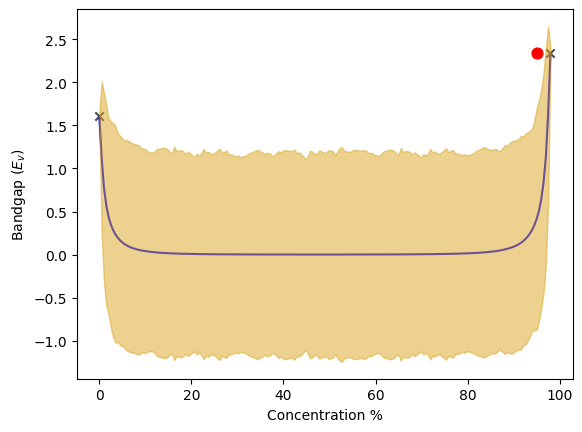

/usr/local/lib/python3.10/dist-packages/gpax/models/gp.py:109: FutureWarning: `noise_prior` is deprecated and will be removed in a future version. Please use `noise_prior_dist` instead, which accepts an instance of a numpyro.distributions Distribution object, e.g., `dist.HalfNormal(scale=0.1)`, rather than a function that calls `numpyro.sample`.
  warnings.warn(
sample: 100%|██████████| 4000/4000 [00:18<00:00, 218.91it/s, 511 steps of size 7.95e-03. acc. prob=0.88]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
         a1      1.84      0.45      1.83      1.13      2.60   1490.50      1.00
         a2      2.00      0.49      1.98      1.20      2.84   2598.30      1.00
         a3      1.85      0.46      1.84      1.15      2.66   1668.88      1.00
         a4      1.85      0.48      1.84      0.97      2.57   1500.35      1.00
         a5      1.98      0.51      1.98      1.15      2.84   2217.94      1.00
          b      1.63      0.59      1.64      0.74      2.68   1480.18      1.00
         b1      2.10      0.47      2.11      1.34      2.90   1596.42      1.00
         b2      1.99      0.49      1.98      1.16      2.72   2886.05      1.00
         b3      2.09      0.45      2.10      1.30      2.76   1727.01      1.00
         b4      2.11      0.45      2.11      1.37      2.83   1954.23      1.00
         b5      1.99      0.53      2.02      1.11      2.85   1514.66      1.00
k_length[0]    

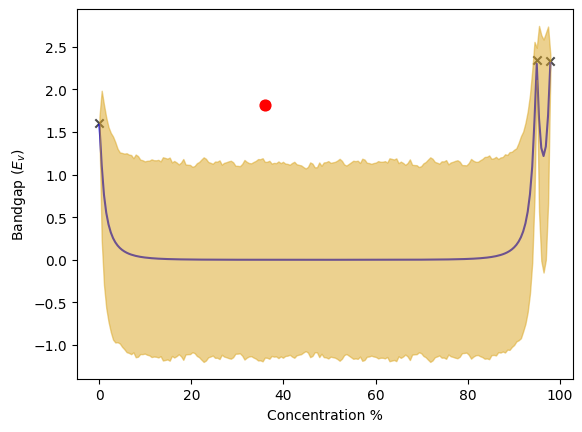

/usr/local/lib/python3.10/dist-packages/gpax/models/gp.py:109: FutureWarning: `noise_prior` is deprecated and will be removed in a future version. Please use `noise_prior_dist` instead, which accepts an instance of a numpyro.distributions Distribution object, e.g., `dist.HalfNormal(scale=0.1)`, rather than a function that calls `numpyro.sample`.
  warnings.warn(
sample: 100%|██████████| 4000/4000 [00:19<00:00, 209.39it/s, 255 steps of size 1.03e-02. acc. prob=0.87]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
         a1      1.97      0.45      1.97      1.28      2.74   1400.34      1.00
         a2      1.99      0.48      1.99      1.23      2.81   1582.08      1.00
         a3      1.97      0.46      1.98      1.22      2.71   1657.97      1.00
         a4      1.96      0.45      1.96      1.20      2.70   1037.98      1.00
         a5      1.97      0.49      1.98      1.21      2.80   1326.27      1.00
          b      0.01      0.03      0.00     -0.01      0.02     38.51      1.00
         b1      1.99      0.47      1.96      1.21      2.75   1200.10      1.00
         b2      1.99      0.49      1.99      1.19      2.82   1602.28      1.00
         b3      1.97      0.45      1.96      1.25      2.73   1301.41      1.00
         b4      2.00      0.46      2.02      1.23      2.75   1518.41      1.00
         b5      1.98      0.50      1.98      1.18      2.84   1653.42      1.00
k_length[0]    

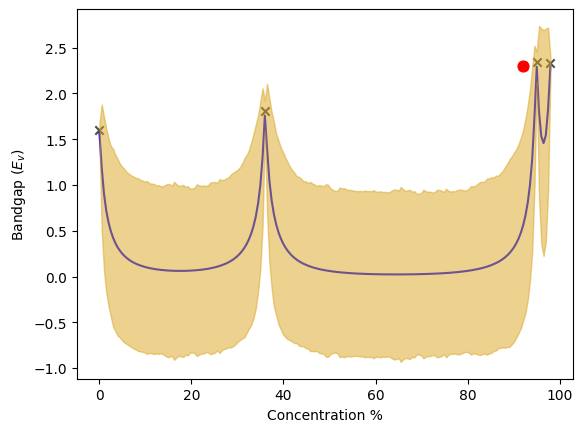

/usr/local/lib/python3.10/dist-packages/gpax/models/gp.py:109: FutureWarning: `noise_prior` is deprecated and will be removed in a future version. Please use `noise_prior_dist` instead, which accepts an instance of a numpyro.distributions Distribution object, e.g., `dist.HalfNormal(scale=0.1)`, rather than a function that calls `numpyro.sample`.
  warnings.warn(
sample: 100%|██████████| 4000/4000 [00:29<00:00, 134.97it/s, 1023 steps of size 5.29e-03. acc. prob=0.93]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
         a1      1.97      0.45      1.97      1.22      2.67   1523.05      1.00
         a2      1.97      0.47      1.96      1.22      2.77   1730.96      1.00
         a3      1.95      0.45      1.93      1.27      2.73   1789.50      1.00
         a4      1.95      0.45      1.93      1.23      2.69   1238.50      1.00
         a5      1.99      0.50      2.00      1.15      2.81   1726.64      1.00
          b      0.00      0.01      0.00     -0.01      0.01    385.74      1.00
         b1      1.98      0.46      1.99      1.17      2.67   1864.59      1.00
         b2      1.98      0.49      1.98      1.13      2.72   1645.93      1.00
         b3      1.95      0.45      1.93      1.25      2.73   1609.09      1.00
         b4      1.95      0.44      1.95      1.19      2.67   1699.47      1.00
         b5      1.99      0.52      1.99      1.13      2.83   1654.91      1.00
k_length[0]    

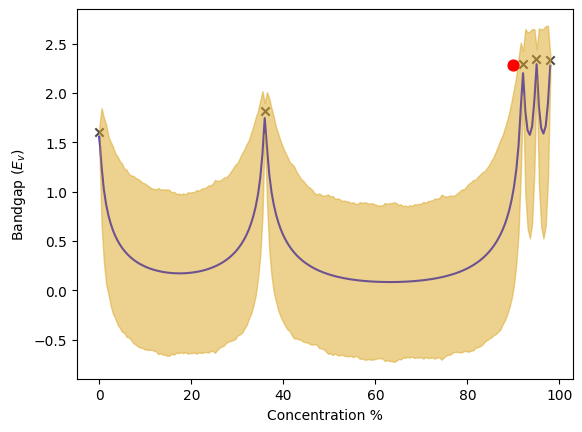

/usr/local/lib/python3.10/dist-packages/gpax/models/gp.py:109: FutureWarning: `noise_prior` is deprecated and will be removed in a future version. Please use `noise_prior_dist` instead, which accepts an instance of a numpyro.distributions Distribution object, e.g., `dist.HalfNormal(scale=0.1)`, rather than a function that calls `numpyro.sample`.
  warnings.warn(
sample: 100%|██████████| 4000/4000 [00:27<00:00, 146.51it/s, 1023 steps of size 6.32e-03. acc. prob=0.90]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
         a1      1.95      0.44      1.95      1.22      2.64    934.88      1.00
         a2      1.96      0.47      1.98      1.18      2.71   1599.47      1.00
         a3      1.97      0.45      1.97      1.24      2.70   1226.18      1.00
         a4      1.96      0.45      1.95      1.23      2.70   1387.09      1.00
         a5      1.96      0.49      1.97      1.08      2.71   1464.53      1.00
          b      0.00      0.01      0.00     -0.00      0.01    298.84      1.00
         b1      1.96      0.46      1.96      1.21      2.72   1231.96      1.00
         b2      1.98      0.48      1.99      1.22      2.79   1503.96      1.00
         b3      1.96      0.45      1.96      1.27      2.76   1330.44      1.00
         b4      1.94      0.46      1.94      1.18      2.66   1659.27      1.00
         b5      1.97      0.50      1.97      1.14      2.76   1636.57      1.00
k_length[0]    

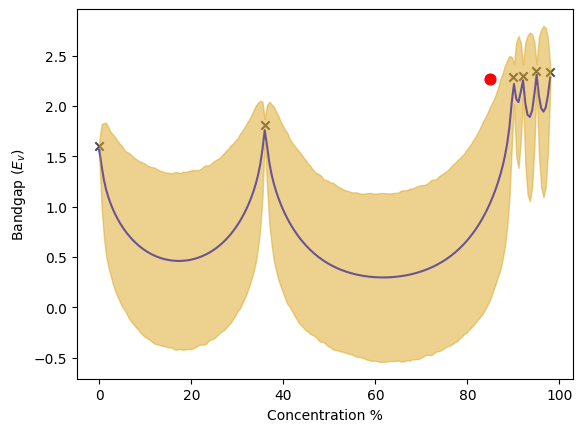

/usr/local/lib/python3.10/dist-packages/gpax/models/gp.py:109: FutureWarning: `noise_prior` is deprecated and will be removed in a future version. Please use `noise_prior_dist` instead, which accepts an instance of a numpyro.distributions Distribution object, e.g., `dist.HalfNormal(scale=0.1)`, rather than a function that calls `numpyro.sample`.
  warnings.warn(
sample: 100%|██████████| 4000/4000 [00:38<00:00, 103.10it/s, 1023 steps of size 4.17e-03. acc. prob=0.93]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
         a1      1.96      0.45      1.95      1.25      2.69   2392.56      1.00
         a2      1.96      0.49      1.98      1.18      2.76   2154.86      1.00
         a3      1.94      0.46      1.94      1.19      2.68   2326.69      1.00
         a4      1.94      0.46      1.93      1.21      2.69   1846.56      1.00
         a5      1.98      0.48      1.98      1.24      2.78   2305.69      1.00
          b      0.00      0.01      0.00     -0.00      0.01    420.63      1.00
         b1      1.94      0.47      1.93      1.20      2.72   2338.30      1.00
         b2      1.98      0.48      1.96      1.24      2.80   2124.60      1.00
         b3      1.98      0.45      1.97      1.24      2.71   1902.87      1.00
         b4      1.96      0.46      1.95      1.24      2.78   2014.44      1.00
         b5      1.98      0.49      2.00      1.15      2.72   2151.78      1.00
k_length[0]    

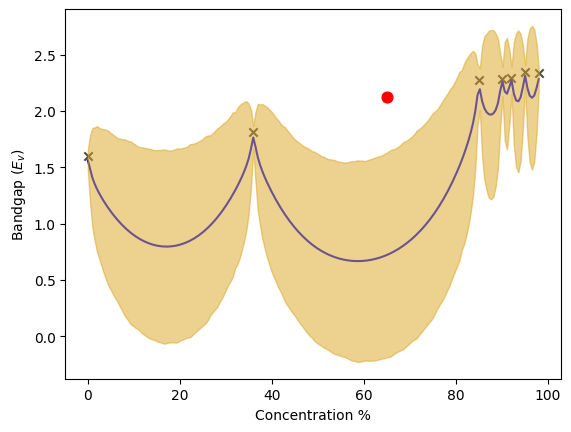

/usr/local/lib/python3.10/dist-packages/gpax/models/gp.py:109: FutureWarning: `noise_prior` is deprecated and will be removed in a future version. Please use `noise_prior_dist` instead, which accepts an instance of a numpyro.distributions Distribution object, e.g., `dist.HalfNormal(scale=0.1)`, rather than a function that calls `numpyro.sample`.
  warnings.warn(
sample: 100%|██████████| 4000/4000 [00:27<00:00, 145.69it/s, 511 steps of size 7.65e-03. acc. prob=0.85]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
         a1      1.96      0.44      1.97      1.25      2.67   1000.51      1.00
         a2      1.98      0.47      1.99      1.21      2.76   1975.70      1.00
         a3      1.95      0.46      1.95      1.17      2.64    764.58      1.00
         a4      1.92      0.45      1.92      1.25      2.74   1501.26      1.00
         a5      1.95      0.49      1.95      1.17      2.80   1240.02      1.00
          b      0.00      0.00      0.00     -0.00      0.00    512.13      1.00
         b1      1.95      0.47      1.95      1.19      2.72   1286.58      1.00
         b2      1.98      0.49      2.00      1.19      2.78   1507.49      1.00
         b3      1.94      0.45      1.93      1.22      2.74   1565.66      1.00
         b4      1.96      0.44      1.94      1.24      2.65   1975.72      1.00
         b5      1.97      0.51      1.97      1.15      2.81    955.71      1.01
k_length[0]    

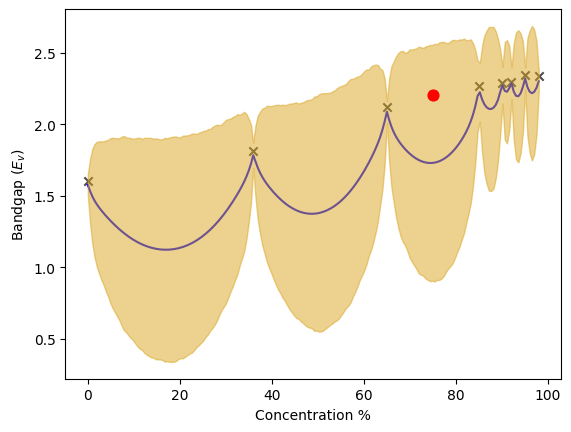

/usr/local/lib/python3.10/dist-packages/gpax/models/gp.py:109: FutureWarning: `noise_prior` is deprecated and will be removed in a future version. Please use `noise_prior_dist` instead, which accepts an instance of a numpyro.distributions Distribution object, e.g., `dist.HalfNormal(scale=0.1)`, rather than a function that calls `numpyro.sample`.
  warnings.warn(
sample: 100%|██████████| 4000/4000 [00:34<00:00, 116.74it/s, 511 steps of size 7.51e-03. acc. prob=0.91]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
         a1      1.95      0.44      1.94      1.23      2.69   1665.72      1.00
         a2      1.99      0.45      1.99      1.22      2.69   2137.22      1.00
         a3      1.95      0.46      1.95      1.19      2.69   1674.98      1.00
         a4      1.96      0.46      1.95      1.20      2.71   1646.77      1.00
         a5      1.98      0.49      1.99      1.13      2.76   2089.46      1.00
          b      0.00      0.00      0.00     -0.00      0.00    419.67      1.00
         b1      1.95      0.47      1.95      1.23      2.73   1319.03      1.00
         b2      1.97      0.50      1.97      1.19      2.82   2170.00      1.00
         b3      1.96      0.44      1.96      1.23      2.69   1810.61      1.00
         b4      1.96      0.45      1.95      1.25      2.69   2007.41      1.00
         b5      1.97      0.50      1.96      1.12      2.78   1668.36      1.00
k_length[0]    

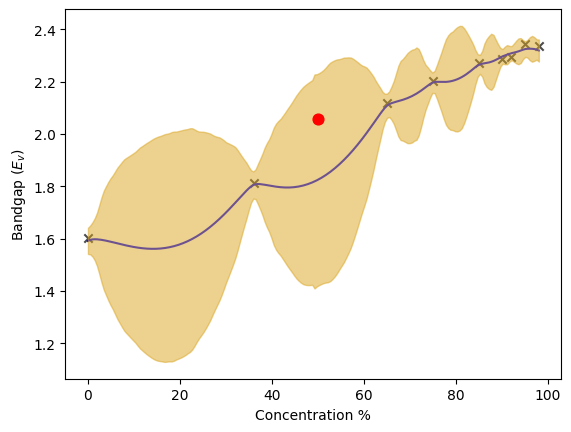

/usr/local/lib/python3.10/dist-packages/gpax/models/gp.py:109: FutureWarning: `noise_prior` is deprecated and will be removed in a future version. Please use `noise_prior_dist` instead, which accepts an instance of a numpyro.distributions Distribution object, e.g., `dist.HalfNormal(scale=0.1)`, rather than a function that calls `numpyro.sample`.
  warnings.warn(
sample: 100%|██████████| 4000/4000 [00:28<00:00, 138.77it/s, 3 steps of size 1.18e-02. acc. prob=0.74]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
         a1      2.03      0.43      2.07      1.29      2.68    379.19      1.00
         a2      1.97      0.46      1.94      1.25      2.72    228.90      1.00
         a3      1.98      0.44      1.97      1.31      2.73    846.78      1.01
         a4      1.91      0.52      1.94      0.90      2.61     53.40      1.04
         a5      2.03      0.57      2.00      1.00      2.99     35.92      1.03
          b      0.00      0.00      0.00     -0.00      0.00    242.47      1.01
         b1      2.00      0.47      2.04      1.27      2.74    328.52      1.00
         b2      1.95      0.47      1.96      1.21      2.72    244.07      1.02
         b3      1.86      0.60      1.95      0.89      2.83     30.50      1.05
         b4      1.99      0.46      2.00      1.28      2.72    339.98      1.02
         b5      2.08      0.55      2.08      1.25      2.93     65.51      1.00
k_length[0]    

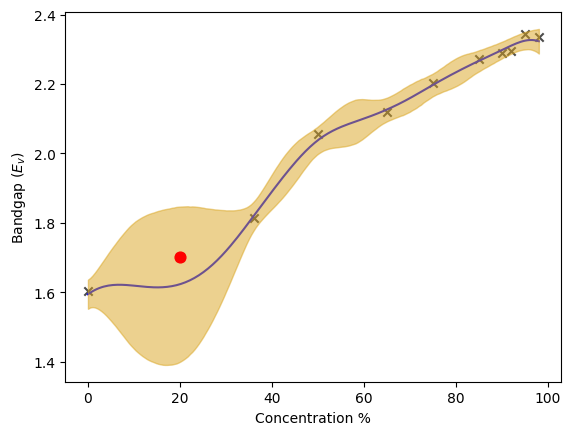

/usr/local/lib/python3.10/dist-packages/gpax/models/gp.py:109: FutureWarning: `noise_prior` is deprecated and will be removed in a future version. Please use `noise_prior_dist` instead, which accepts an instance of a numpyro.distributions Distribution object, e.g., `dist.HalfNormal(scale=0.1)`, rather than a function that calls `numpyro.sample`.
  warnings.warn(
sample: 100%|██████████| 4000/4000 [00:40<00:00, 97.91it/s, 255 steps of size 8.46e-03. acc. prob=0.89] 



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
         a1      1.95      0.45      1.93      1.19      2.68   1893.05      1.00
         a2      1.98      0.47      1.97      1.21      2.78   2175.78      1.00
         a3      1.95      0.47      1.94      1.26      2.78   1651.77      1.00
         a4      1.96      0.47      1.94      1.23      2.75   1569.35      1.00
         a5      1.98      0.48      1.98      1.23      2.81   2570.50      1.00
          b      0.00      0.00      0.00     -0.00      0.00    447.41      1.00
         b1      1.95      0.46      1.93      1.20      2.69   1834.56      1.00
         b2      1.97      0.49      1.97      1.17      2.80   2048.16      1.00
         b3      1.95      0.45      1.96      1.21      2.65   1975.15      1.00
         b4      1.95      0.46      1.95      1.23      2.74   1967.68      1.00
         b5      1.96      0.50      1.96      1.11      2.76   2299.78      1.00
k_length[0]    

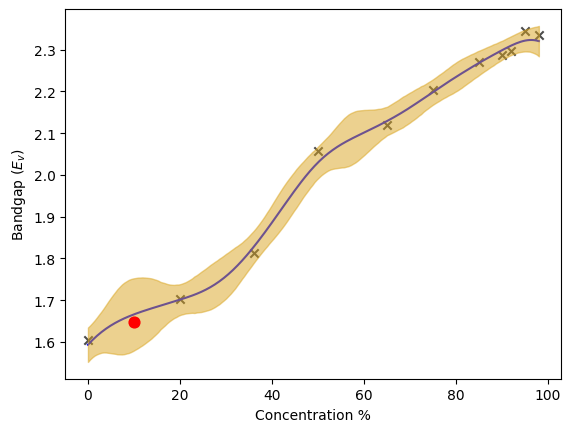

/usr/local/lib/python3.10/dist-packages/gpax/models/gp.py:109: FutureWarning: `noise_prior` is deprecated and will be removed in a future version. Please use `noise_prior_dist` instead, which accepts an instance of a numpyro.distributions Distribution object, e.g., `dist.HalfNormal(scale=0.1)`, rather than a function that calls `numpyro.sample`.
  warnings.warn(
sample: 100%|██████████| 4000/4000 [00:26<00:00, 153.27it/s, 3 steps of size 9.34e-03. acc. prob=0.30] 



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
         a1      2.13      0.23      2.17      1.65      2.31     37.00      1.07
         a2      1.56      0.32      1.44      1.34      2.16      7.41      1.23
         a3      2.26      0.29      2.36      1.68      2.43     11.30      1.15
         a4      2.28      0.28      2.37      1.72      2.45     13.86      1.11
         a5      1.48      0.37      1.32      1.24      2.18      6.44      1.23
          b      0.00      0.00      0.00     -0.00      0.00    207.51      1.01
         b1      1.68      0.27      1.61      1.48      2.18      7.91      1.29
         b2      1.73      0.27      1.67      1.49      2.25     25.89      1.09
         b3      1.07      0.55      0.80      0.73      2.07      4.92      1.32
         b4      1.24      0.47      1.04      0.86      2.07      5.25      1.32
         b5      1.94      0.24      1.94      1.60      2.36    116.37      1.05
k_length[0]    

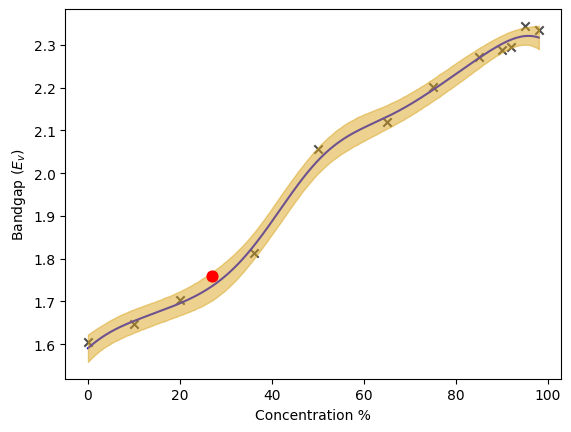

/usr/local/lib/python3.10/dist-packages/gpax/models/gp.py:109: FutureWarning: `noise_prior` is deprecated and will be removed in a future version. Please use `noise_prior_dist` instead, which accepts an instance of a numpyro.distributions Distribution object, e.g., `dist.HalfNormal(scale=0.1)`, rather than a function that calls `numpyro.sample`.
  warnings.warn(
sample: 100%|██████████| 4000/4000 [00:46<00:00, 86.04it/s, 511 steps of size 7.37e-03. acc. prob=0.92] 



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
         a1      1.96      0.44      1.94      1.23      2.66   1509.34      1.00
         a2      1.97      0.48      1.98      1.14      2.70   2395.81      1.00
         a3      1.98      0.46      1.97      1.24      2.71   1948.58      1.00
         a4      1.96      0.46      1.95      1.28      2.79   1921.07      1.00
         a5      1.98      0.51      1.99      1.16      2.82   1634.35      1.00
          b      0.00      0.01      0.00     -0.00      0.00     24.17      1.04
         b1      1.95      0.47      1.95      1.21      2.75   1584.90      1.00
         b2      1.99      0.49      1.98      1.09      2.66   2171.80      1.00
         b3      1.94      0.45      1.94      1.15      2.62   2107.38      1.00
         b4      1.95      0.45      1.95      1.25      2.69   2200.31      1.00
         b5      1.98      0.52      1.99      1.17      2.88   1636.33      1.00
k_length[0]    

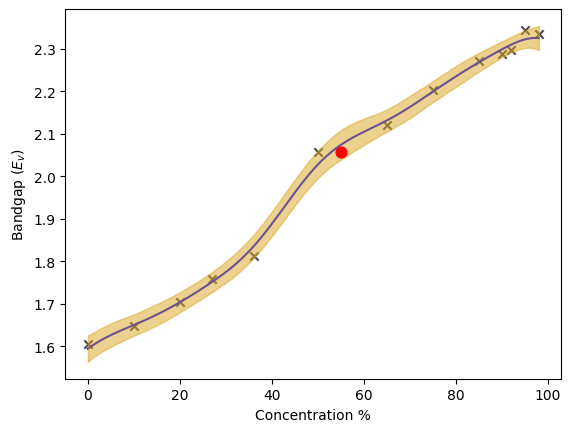

/usr/local/lib/python3.10/dist-packages/gpax/models/gp.py:109: FutureWarning: `noise_prior` is deprecated and will be removed in a future version. Please use `noise_prior_dist` instead, which accepts an instance of a numpyro.distributions Distribution object, e.g., `dist.HalfNormal(scale=0.1)`, rather than a function that calls `numpyro.sample`.
  warnings.warn(
sample: 100%|██████████| 4000/4000 [00:54<00:00, 72.77it/s, 511 steps of size 6.04e-03. acc. prob=0.89]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
         a1      1.96      0.45      1.95      1.23      2.71   1442.82      1.00
         a2      1.98      0.47      1.98      1.26      2.81   1491.58      1.00
         a3      1.95      0.45      1.96      1.23      2.68   1158.11      1.00
         a4      1.95      0.46      1.95      1.23      2.74   1012.33      1.00
         a5      1.99      0.49      1.98      1.20      2.78   1486.48      1.00
          b      0.00      0.01      0.00     -0.00      0.00    297.99      1.00
         b1      1.95      0.49      1.94      1.16      2.71   1038.58      1.00
         b2      1.98      0.51      1.99      1.21      2.88   1494.82      1.00
         b3      1.95      0.45      1.94      1.18      2.64   1258.02      1.00
         b4      1.96      0.44      1.96      1.26      2.73   1306.83      1.00
         b5      1.99      0.50      1.98      1.11      2.75   1299.54      1.00
k_length[0]    

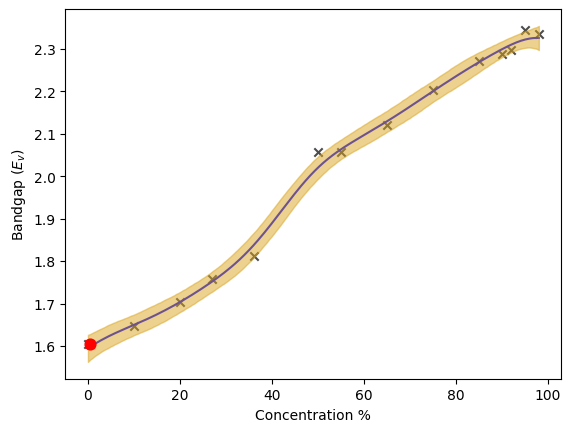

/usr/local/lib/python3.10/dist-packages/gpax/models/gp.py:109: FutureWarning: `noise_prior` is deprecated and will be removed in a future version. Please use `noise_prior_dist` instead, which accepts an instance of a numpyro.distributions Distribution object, e.g., `dist.HalfNormal(scale=0.1)`, rather than a function that calls `numpyro.sample`.
  warnings.warn(
sample: 100%|██████████| 4000/4000 [00:53<00:00, 74.54it/s, 255 steps of size 9.25e-03. acc. prob=0.87]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
         a1      1.94      0.45      1.93      1.14      2.61   1401.33      1.00
         a2      1.99      0.47      1.99      1.21      2.77   2015.30      1.00
         a3      1.96      0.47      1.96      1.16      2.71   1565.20      1.00
         a4      1.98      0.47      1.96      1.18      2.73   1346.25      1.00
         a5      2.00      0.49      2.00      1.22      2.83   1764.12      1.00
          b      0.00      0.00      0.00     -0.00      0.00    816.15      1.00
         b1      1.95      0.46      1.94      1.21      2.74   1371.89      1.00
         b2      2.00      0.48      1.99      1.21      2.80   1782.94      1.00
         b3      1.97      0.44      1.96      1.25      2.69   1754.31      1.00
         b4      1.96      0.44      1.94      1.26      2.72   1584.29      1.00
         b5      1.97      0.50      1.99      1.23      2.81   1737.54      1.00
k_length[0]    

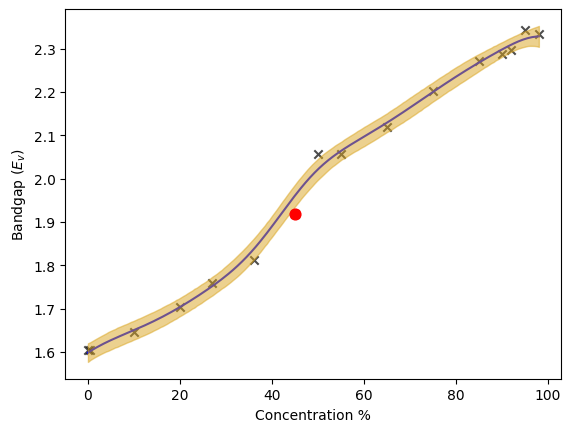

/usr/local/lib/python3.10/dist-packages/gpax/models/gp.py:109: FutureWarning: `noise_prior` is deprecated and will be removed in a future version. Please use `noise_prior_dist` instead, which accepts an instance of a numpyro.distributions Distribution object, e.g., `dist.HalfNormal(scale=0.1)`, rather than a function that calls `numpyro.sample`.
  warnings.warn(
sample: 100%|██████████| 4000/4000 [00:50<00:00, 78.60it/s, 511 steps of size 7.50e-03. acc. prob=0.91]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
         a1      1.95      0.45      1.96      1.22      2.69   1807.91      1.00
         a2      1.98      0.47      1.98      1.27      2.80   2057.92      1.00
         a3      1.96      0.46      1.96      1.22      2.69   1887.49      1.00
         a4      1.97      0.46      1.96      1.23      2.72   1986.58      1.00
         a5      1.97      0.50      1.98      1.12      2.75   2343.52      1.00
          b      0.00      0.00      0.00     -0.00      0.00    733.27      1.00
         b1      1.95      0.47      1.93      1.14      2.69   1552.59      1.00
         b2      1.99      0.49      1.97      1.15      2.74   1998.57      1.00
         b3      1.95      0.45      1.95      1.23      2.70   1839.35      1.00
         b4      1.97      0.46      1.96      1.22      2.72   2029.06      1.00
         b5      1.97      0.50      1.99      1.16      2.82   2166.92      1.00
k_length[0]    

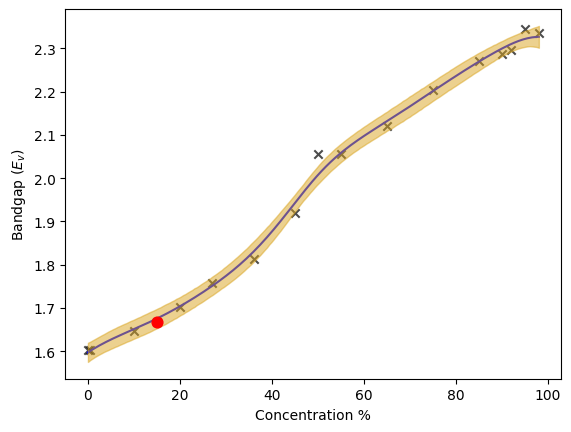

/usr/local/lib/python3.10/dist-packages/gpax/models/gp.py:109: FutureWarning: `noise_prior` is deprecated and will be removed in a future version. Please use `noise_prior_dist` instead, which accepts an instance of a numpyro.distributions Distribution object, e.g., `dist.HalfNormal(scale=0.1)`, rather than a function that calls `numpyro.sample`.
  warnings.warn(
sample: 100%|██████████| 4000/4000 [00:56<00:00, 70.35it/s, 511 steps of size 6.79e-03. acc. prob=0.87]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
         a1      1.97      0.43      1.97      1.24      2.66   1433.48      1.00
         a2      1.98      0.47      1.98      1.28      2.81   1196.79      1.00
         a3      1.94      0.46      1.93      1.21      2.68    841.08      1.01
         a4      1.98      0.45      1.97      1.24      2.68   1240.39      1.00
         a5      1.98      0.48      1.98      1.15      2.75   1830.67      1.00
          b      0.00      0.00      0.00     -0.00      0.00    213.86      1.00
         b1      1.96      0.46      1.97      1.19      2.72   1393.66      1.00
         b2      1.97      0.51      1.97      1.17      2.79   1089.17      1.00
         b3      1.97      0.44      1.97      1.22      2.68   1321.96      1.00
         b4      1.96      0.45      1.95      1.14      2.62   1671.70      1.00
         b5      2.00      0.53      2.00      1.12      2.90    267.66      1.00
k_length[0]    

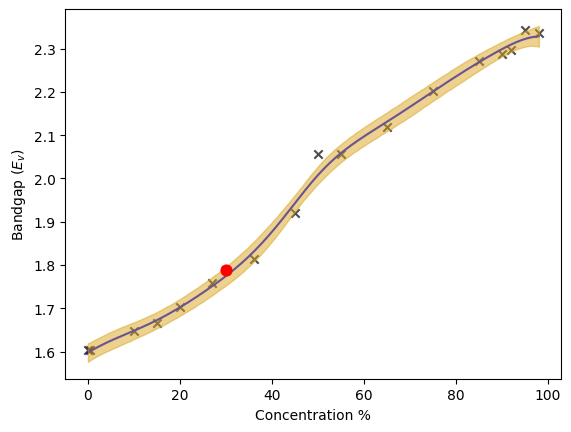

/usr/local/lib/python3.10/dist-packages/gpax/models/gp.py:109: FutureWarning: `noise_prior` is deprecated and will be removed in a future version. Please use `noise_prior_dist` instead, which accepts an instance of a numpyro.distributions Distribution object, e.g., `dist.HalfNormal(scale=0.1)`, rather than a function that calls `numpyro.sample`.
  warnings.warn(
sample: 100%|██████████| 4000/4000 [01:01<00:00, 65.50it/s, 511 steps of size 8.50e-03. acc. prob=0.89]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
         a1      1.96      0.44      1.96      1.31      2.72   2164.37      1.00
         a2      1.98      0.47      1.98      1.17      2.72   2261.03      1.00
         a3      1.97      0.46      1.97      1.18      2.70   2193.43      1.00
         a4      1.96      0.46      1.96      1.23      2.72   2257.84      1.00
         a5      1.99      0.50      1.99      1.12      2.75   2435.52      1.00
          b      0.00      0.00      0.00     -0.00      0.00    572.72      1.00
         b1      1.96      0.45      1.95      1.20      2.70   1829.05      1.00
         b2      1.98      0.49      1.98      1.18      2.82   2446.77      1.00
         b3      1.96      0.44      1.95      1.22      2.67   2036.55      1.00
         b4      1.96      0.45      1.94      1.19      2.68   2226.09      1.00
         b5      1.97      0.51      1.97      1.07      2.74   1955.82      1.00
k_length[0]    

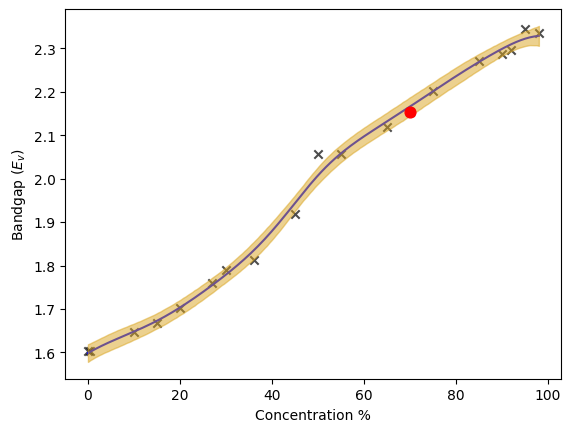

/usr/local/lib/python3.10/dist-packages/gpax/models/gp.py:109: FutureWarning: `noise_prior` is deprecated and will be removed in a future version. Please use `noise_prior_dist` instead, which accepts an instance of a numpyro.distributions Distribution object, e.g., `dist.HalfNormal(scale=0.1)`, rather than a function that calls `numpyro.sample`.
  warnings.warn(
sample: 100%|██████████| 4000/4000 [01:34<00:00, 42.26it/s, 511 steps of size 7.74e-03. acc. prob=0.91]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
         a1      1.95      0.45      1.94      1.22      2.68   1549.57      1.00
         a2      1.97      0.47      1.96      1.23      2.76   2418.34      1.00
         a3      1.98      0.46      1.97      1.26      2.73   1995.88      1.00
         a4      1.97      0.47      1.95      1.22      2.74   2177.92      1.00
         a5      1.97      0.51      1.97      1.16      2.80   2126.47      1.00
          b      0.00      0.00      0.00     -0.00      0.00    482.90      1.00
         b1      1.94      0.47      1.94      1.12      2.68   1769.69      1.00
         b2      1.97      0.50      1.95      1.16      2.81   2344.32      1.00
         b3      1.96      0.45      1.95      1.26      2.73   2182.16      1.00
         b4      1.96      0.45      1.95      1.21      2.71   1875.85      1.00
         b5      1.98      0.51      1.99      1.11      2.78   1989.40      1.00
k_length[0]    

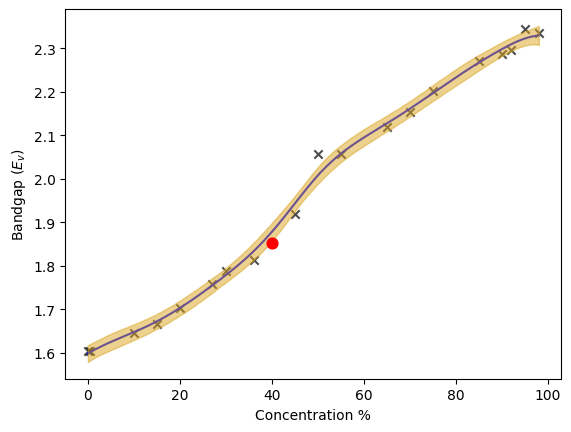

/usr/local/lib/python3.10/dist-packages/gpax/models/gp.py:109: FutureWarning: `noise_prior` is deprecated and will be removed in a future version. Please use `noise_prior_dist` instead, which accepts an instance of a numpyro.distributions Distribution object, e.g., `dist.HalfNormal(scale=0.1)`, rather than a function that calls `numpyro.sample`.
  warnings.warn(
sample: 100%|██████████| 4000/4000 [01:06<00:00, 60.49it/s, 390 steps of size 9.16e-03. acc. prob=0.87]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
         a1      1.97      0.44      1.96      1.26      2.71   1473.77      1.00
         a2      1.98      0.47      1.98      1.19      2.76   1866.42      1.00
         a3      1.97      0.46      1.95      1.28      2.78   1510.53      1.00
         a4      1.95      0.47      1.95      1.13      2.68   2047.62      1.00
         a5      1.99      0.49      2.00      1.18      2.77   1780.04      1.00
          b      0.00      0.00      0.00     -0.00      0.00    109.29      1.00
         b1      1.95      0.47      1.93      1.20      2.73   1542.87      1.00
         b2      1.96      0.50      1.97      1.15      2.73   2225.94      1.00
         b3      1.95      0.42      1.95      1.30      2.64   2173.53      1.00
         b4      1.95      0.46      1.94      1.21      2.74   1887.44      1.00
         b5      1.96      0.51      1.96      1.07      2.72   1268.87      1.00
k_length[0]    

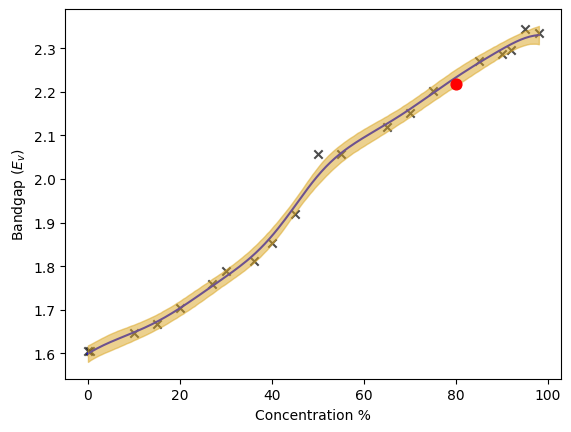

/usr/local/lib/python3.10/dist-packages/gpax/models/gp.py:109: FutureWarning: `noise_prior` is deprecated and will be removed in a future version. Please use `noise_prior_dist` instead, which accepts an instance of a numpyro.distributions Distribution object, e.g., `dist.HalfNormal(scale=0.1)`, rather than a function that calls `numpyro.sample`.
  warnings.warn(
sample: 100%|██████████| 4000/4000 [01:17<00:00, 51.53it/s, 511 steps of size 7.23e-03. acc. prob=0.91]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
         a1      1.95      0.45      1.95      1.22      2.71   1665.16      1.00
         a2      1.98      0.47      1.97      1.21      2.77   2596.81      1.00
         a3      1.97      0.45      1.96      1.23      2.70   2171.30      1.00
         a4      1.97      0.47      1.96      1.18      2.74   1865.39      1.00
         a5      1.97      0.50      1.99      1.16      2.79   2113.73      1.00
          b      0.00      0.00      0.00     -0.00      0.00    200.85      1.00
         b1      1.95      0.47      1.94      1.08      2.65   1220.81      1.00
         b2      1.98      0.50      1.99      1.21      2.83   2474.91      1.00
         b3      1.95      0.45      1.93      1.22      2.70   1802.09      1.00
         b4      1.97      0.46      1.98      1.21      2.74   1817.88      1.00
         b5      1.97      0.50      1.96      1.13      2.79   1810.45      1.00
k_length[0]    

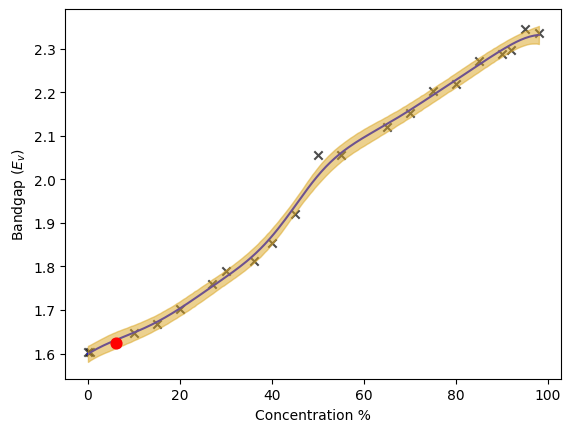

/usr/local/lib/python3.10/dist-packages/gpax/models/gp.py:109: FutureWarning: `noise_prior` is deprecated and will be removed in a future version. Please use `noise_prior_dist` instead, which accepts an instance of a numpyro.distributions Distribution object, e.g., `dist.HalfNormal(scale=0.1)`, rather than a function that calls `numpyro.sample`.
  warnings.warn(
sample: 100%|██████████| 4000/4000 [01:21<00:00, 49.27it/s, 511 steps of size 8.54e-03. acc. prob=0.83]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
         a1      1.97      0.45      1.95      1.23      2.69   1345.39      1.00
         a2      1.97      0.49      1.96      1.23      2.82   1413.11      1.00
         a3      1.95      0.47      1.96      1.25      2.74   1253.40      1.00
         a4      1.94      0.46      1.93      1.24      2.74   1470.44      1.00
         a5      1.99      0.51      2.00      1.15      2.80   1467.33      1.00
          b      0.00      0.00      0.00     -0.00      0.00    797.08      1.00
         b1      1.94      0.46      1.93      1.22      2.73   1299.64      1.00
         b2      1.97      0.49      1.97      1.17      2.83   2098.86      1.00
         b3      1.94      0.45      1.94      1.24      2.71   1668.36      1.00
         b4      1.97      0.45      1.95      1.31      2.75   1473.52      1.00
         b5      1.97      0.51      1.98      1.07      2.73   1169.49      1.00
k_length[0]    

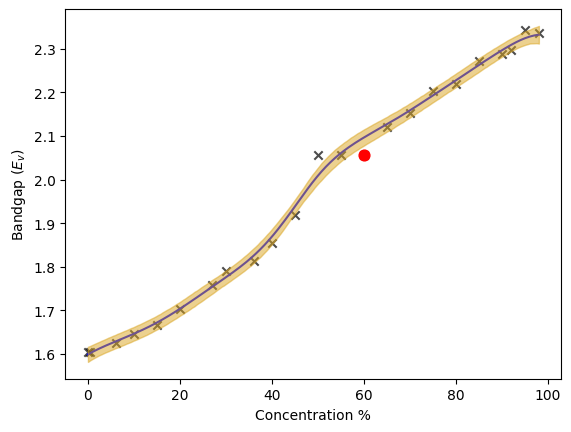

/usr/local/lib/python3.10/dist-packages/gpax/models/gp.py:109: FutureWarning: `noise_prior` is deprecated and will be removed in a future version. Please use `noise_prior_dist` instead, which accepts an instance of a numpyro.distributions Distribution object, e.g., `dist.HalfNormal(scale=0.1)`, rather than a function that calls `numpyro.sample`.
  warnings.warn(
sample: 100%|██████████| 4000/4000 [01:38<00:00, 40.58it/s, 511 steps of size 8.38e-03. acc. prob=0.89]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
         a1      1.94      0.45      1.94      1.28      2.72   1559.84      1.00
         a2      1.98      0.46      1.98      1.14      2.67   2301.80      1.00
         a3      1.97      0.46      1.97      1.26      2.76   1792.33      1.00
         a4      1.95      0.46      1.95      1.16      2.68   2096.13      1.00
         a5      1.98      0.50      1.98      1.12      2.77   2358.43      1.00
          b      0.01      0.05      0.00     -0.00      0.00     19.42      1.06
         b1      1.96      0.46      1.94      1.12      2.67   1577.59      1.00
         b2      1.98      0.49      1.97      1.16      2.76   2163.03      1.00
         b3      1.96      0.43      1.97      1.25      2.66   2033.48      1.00
         b4      1.96      0.45      1.95      1.23      2.73   2193.13      1.00
         b5      1.99      0.50      1.99      1.15      2.81   2022.24      1.00
k_length[0]    

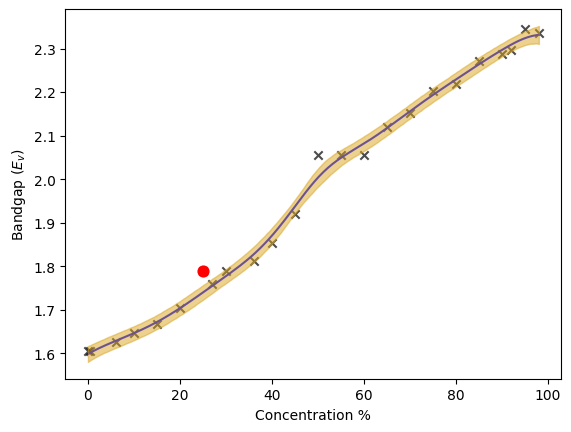

/usr/local/lib/python3.10/dist-packages/gpax/models/gp.py:109: FutureWarning: `noise_prior` is deprecated and will be removed in a future version. Please use `noise_prior_dist` instead, which accepts an instance of a numpyro.distributions Distribution object, e.g., `dist.HalfNormal(scale=0.1)`, rather than a function that calls `numpyro.sample`.
  warnings.warn(
sample: 100%|██████████| 4000/4000 [01:19<00:00, 50.08it/s, 511 steps of size 9.62e-03. acc. prob=0.83]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
         a1      1.95      0.46      1.95      1.14      2.65    418.83      1.00
         a2      1.94      0.52      1.96      1.16      2.84    252.79      1.01
         a3      1.97      0.47      1.95      1.17      2.67    640.49      1.00
         a4      1.97      0.46      1.97      1.25      2.73   1267.13      1.00
         a5      1.97      0.48      1.99      1.14      2.71   1498.72      1.01
          b      0.00      0.00      0.00     -0.00      0.00    280.95      1.01
         b1      1.96      0.45      1.96      1.22      2.66   1116.10      1.00
         b2      1.97      0.47      1.96      1.21      2.78   1385.47      1.00
         b3      1.93      0.45      1.93      1.27      2.72   1315.63      1.00
         b4      1.97      0.46      1.96      1.27      2.77   1089.61      1.00
         b5      1.98      0.50      1.98      1.14      2.78   1346.84      1.00
k_length[0]    

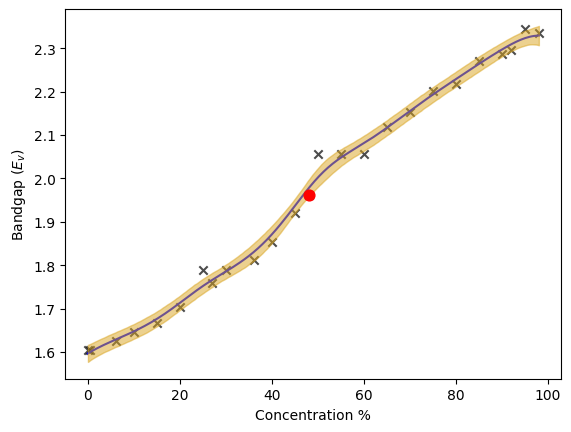

/usr/local/lib/python3.10/dist-packages/gpax/models/gp.py:109: FutureWarning: `noise_prior` is deprecated and will be removed in a future version. Please use `noise_prior_dist` instead, which accepts an instance of a numpyro.distributions Distribution object, e.g., `dist.HalfNormal(scale=0.1)`, rather than a function that calls `numpyro.sample`.
  warnings.warn(
sample: 100%|██████████| 4000/4000 [01:30<00:00, 44.37it/s, 255 steps of size 9.68e-03. acc. prob=0.85]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
         a1      1.95      0.47      1.95      1.15      2.66   1258.64      1.00
         a2      1.99      0.46      1.99      1.14      2.66   1842.64      1.00
         a3      1.95      0.45      1.94      1.21      2.67   1377.07      1.00
         a4      1.95      0.45      1.95      1.21      2.67   1314.41      1.00
         a5      1.98      0.48      1.98      1.18      2.77   1881.17      1.00
          b      0.00      0.01      0.00     -0.00      0.00    105.49      1.00
         b1      1.96      0.47      1.95      1.21      2.77   1269.11      1.00
         b2      1.97      0.50      1.97      1.11      2.79   1852.28      1.00
         b3      1.98      0.46      1.97      1.26      2.76   1430.03      1.00
         b4      1.95      0.47      1.95      1.08      2.64   1445.83      1.00
         b5      1.99      0.49      1.99      1.19      2.81   1498.42      1.00
k_length[0]    

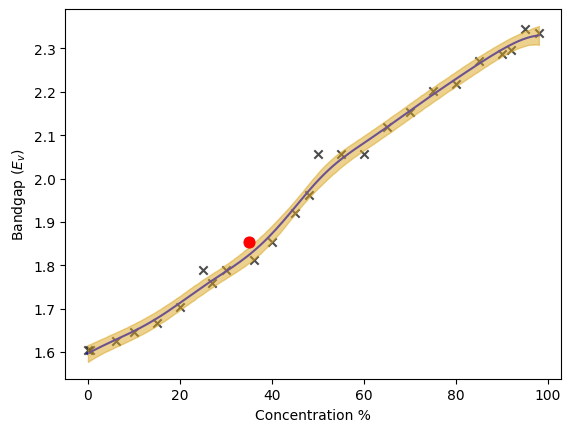

/usr/local/lib/python3.10/dist-packages/gpax/models/gp.py:109: FutureWarning: `noise_prior` is deprecated and will be removed in a future version. Please use `noise_prior_dist` instead, which accepts an instance of a numpyro.distributions Distribution object, e.g., `dist.HalfNormal(scale=0.1)`, rather than a function that calls `numpyro.sample`.
  warnings.warn(
sample: 100%|██████████| 4000/4000 [01:59<00:00, 33.60it/s, 511 steps of size 6.65e-03. acc. prob=0.90]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
         a1      1.95      0.44      1.95      1.21      2.67   1097.19      1.00
         a2      1.99      0.48      2.00      1.15      2.73   2066.50      1.00
         a3      1.96      0.44      1.95      1.28      2.71   1300.38      1.00
         a4      1.96      0.46      1.96      1.25      2.78   1636.42      1.00
         a5      1.98      0.50      1.98      1.21      2.85   1847.38      1.00
          b      0.00      0.00      0.00     -0.00      0.00    209.14      1.01
         b1      1.95      0.48      1.94      1.18      2.75   1143.57      1.00
         b2      1.99      0.49      2.00      1.25      2.87   1639.93      1.00
         b3      1.96      0.45      1.96      1.23      2.70   1445.60      1.00
         b4      1.96      0.45      1.96      1.17      2.64   1465.26      1.00
         b5      1.97      0.51      1.98      1.06      2.73   1542.96      1.00
k_length[0]    

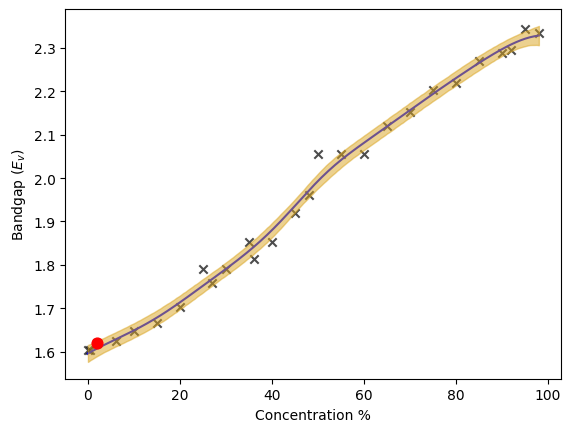

/usr/local/lib/python3.10/dist-packages/gpax/models/gp.py:109: FutureWarning: `noise_prior` is deprecated and will be removed in a future version. Please use `noise_prior_dist` instead, which accepts an instance of a numpyro.distributions Distribution object, e.g., `dist.HalfNormal(scale=0.1)`, rather than a function that calls `numpyro.sample`.
  warnings.warn(
sample: 100%|██████████| 4000/4000 [01:51<00:00, 35.91it/s, 255 steps of size 8.90e-03. acc. prob=0.86]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
         a1      1.96      0.45      1.95      1.26      2.72   1902.05      1.00
         a2      1.97      0.47      1.98      1.16      2.68   2016.31      1.00
         a3      1.97      0.47      1.97      1.23      2.75   1544.31      1.00
         a4      1.95      0.47      1.95      1.18      2.72   1811.04      1.00
         a5      2.00      0.50      2.00      1.19      2.85   1965.61      1.00
          b     -0.00      0.01      0.00     -0.00      0.00    106.74      1.00
         b1      1.93      0.46      1.92      1.17      2.68   1453.66      1.00
         b2      1.98      0.50      1.98      1.09      2.73   2012.68      1.00
         b3      1.96      0.44      1.97      1.29      2.71   1642.56      1.00
         b4      1.96      0.47      1.95      1.22      2.76   1755.40      1.00
         b5      1.99      0.51      2.01      1.13      2.80   1325.14      1.00
k_length[0]    

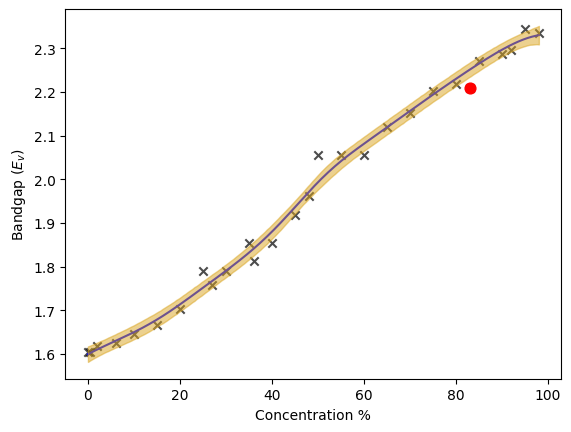

/usr/local/lib/python3.10/dist-packages/gpax/models/gp.py:109: FutureWarning: `noise_prior` is deprecated and will be removed in a future version. Please use `noise_prior_dist` instead, which accepts an instance of a numpyro.distributions Distribution object, e.g., `dist.HalfNormal(scale=0.1)`, rather than a function that calls `numpyro.sample`.
  warnings.warn(
sample: 100%|██████████| 4000/4000 [02:02<00:00, 32.57it/s, 511 steps of size 7.14e-03. acc. prob=0.91]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
         a1      1.96      0.43      1.97      1.28      2.69   1793.14      1.00
         a2      1.97      0.47      1.96      1.24      2.75   2403.88      1.00
         a3      1.96      0.45      1.95      1.18      2.67   1937.87      1.00
         a4      1.96      0.47      1.95      1.19      2.73   1582.65      1.00
         a5      1.97      0.50      1.98      1.20      2.86   1991.28      1.00
          b      0.00      0.00      0.00     -0.00      0.00    141.45      1.00
         b1      1.94      0.47      1.95      1.09      2.64   1658.03      1.00
         b2      1.98      0.50      1.97      1.20      2.83   2142.26      1.00
         b3      1.96      0.44      1.96      1.19      2.66   2036.61      1.00
         b4      1.96      0.46      1.95      1.19      2.69   1755.33      1.00
         b5      1.97      0.51      1.98      1.10      2.79   1641.95      1.00
k_length[0]    

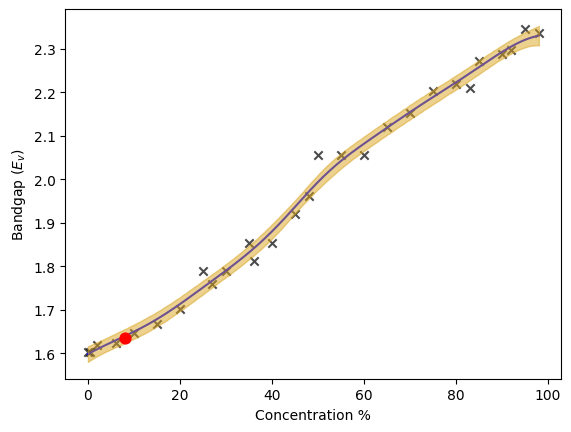

/usr/local/lib/python3.10/dist-packages/gpax/models/gp.py:109: FutureWarning: `noise_prior` is deprecated and will be removed in a future version. Please use `noise_prior_dist` instead, which accepts an instance of a numpyro.distributions Distribution object, e.g., `dist.HalfNormal(scale=0.1)`, rather than a function that calls `numpyro.sample`.
  warnings.warn(
sample: 100%|██████████| 4000/4000 [02:05<00:00, 31.88it/s, 255 steps of size 9.09e-03. acc. prob=0.87]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
         a1      1.97      0.46      1.98      1.26      2.72   1668.57      1.00
         a2      1.98      0.48      1.98      1.21      2.77   1755.12      1.00
         a3      1.97      0.46      1.96      1.28      2.75   1586.08      1.00
         a4      1.97      0.46      1.96      1.22      2.69   1663.87      1.00
         a5      1.99      0.49      2.00      1.22      2.81   1987.57      1.00
          b      0.00      0.00      0.00     -0.00      0.00    764.27      1.00
         b1      1.96      0.47      1.96      1.17      2.67   1227.84      1.00
         b2      1.97      0.50      1.96      1.12      2.75   1873.67      1.00
         b3      1.97      0.44      1.96      1.20      2.65   1985.51      1.00
         b4      1.96      0.46      1.95      1.24      2.73   1451.49      1.00
         b5      1.97      0.51      1.96      1.16      2.81   1995.01      1.00
k_length[0]    

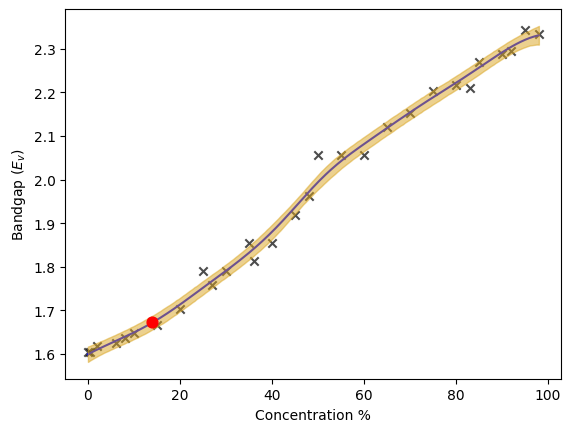

/usr/local/lib/python3.10/dist-packages/gpax/models/gp.py:109: FutureWarning: `noise_prior` is deprecated and will be removed in a future version. Please use `noise_prior_dist` instead, which accepts an instance of a numpyro.distributions Distribution object, e.g., `dist.HalfNormal(scale=0.1)`, rather than a function that calls `numpyro.sample`.
  warnings.warn(
sample: 100%|██████████| 4000/4000 [02:19<00:00, 28.74it/s, 511 steps of size 7.41e-03. acc. prob=0.91]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
         a1      1.96      0.45      1.96      1.26      2.73   1886.02      1.00
         a2      1.97      0.47      1.98      1.19      2.74   2056.14      1.00
         a3      1.97      0.46      1.96      1.19      2.69   1876.47      1.00
         a4      1.96      0.47      1.95      1.22      2.73   2023.15      1.00
         a5      1.98      0.50      1.99      1.17      2.81   2070.31      1.00
          b      0.00      0.00      0.00     -0.00      0.00    267.11      1.00
         b1      1.95      0.48      1.94      1.18      2.75   1845.70      1.00
         b2      1.98      0.49      1.98      1.20      2.77   2057.69      1.00
         b3      1.96      0.44      1.95      1.26      2.71   1957.91      1.00
         b4      1.96      0.44      1.97      1.21      2.64   2094.50      1.00
         b5      1.97      0.50      1.98      1.14      2.76   2299.77      1.00
k_length[0]    

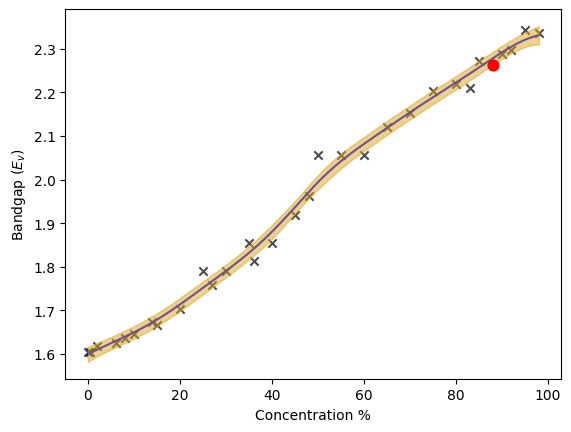

/usr/local/lib/python3.10/dist-packages/gpax/models/gp.py:109: FutureWarning: `noise_prior` is deprecated and will be removed in a future version. Please use `noise_prior_dist` instead, which accepts an instance of a numpyro.distributions Distribution object, e.g., `dist.HalfNormal(scale=0.1)`, rather than a function that calls `numpyro.sample`.
  warnings.warn(
sample: 100%|██████████| 4000/4000 [02:33<00:00, 26.14it/s, 511 steps of size 7.49e-03. acc. prob=0.86]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
         a1      2.00      0.48      1.97      1.20      2.81    107.29      1.02
         a2      1.97      0.46      1.95      1.22      2.75   1798.56      1.00
         a3      2.00      0.46      2.00      1.28      2.82    669.56      1.00
         a4      1.96      0.44      1.93      1.25      2.69   1647.69      1.00
         a5      1.96      0.48      1.94      1.17      2.76   1564.62      1.00
          b      0.00      0.00      0.00     -0.00      0.00    457.58      1.00
         b1      1.97      0.46      1.99      1.16      2.67   1038.43      1.00
         b2      2.00      0.50      1.98      1.14      2.75   1386.77      1.00
         b3      1.97      0.45      1.97      1.15      2.60    491.73      1.00
         b4      2.00      0.48      1.98      1.32      2.86    181.09      1.00
         b5      1.99      0.52      1.98      1.22      2.86    166.63      1.01
k_length[0]    

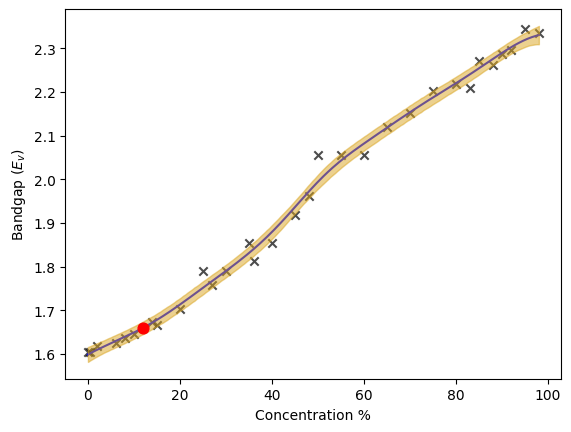

In [ ]:
from gpax import acquisition
# Given data
compositions = [0, 0.5, 2, 4, 5, 6, 8, 10, 12, 14, 15, 20, 25, 27, 30, 35, 36, 40, 43, 45, 48, 50, 55, 60, 65, 70, 75, 80, 83, 85, 88, 90, 92, 95, 98]
bandgaps = [1.60413972, 1.60413972,1.61879896, 1.61038961, 1.61038961, 1.62516383, 1.63588391, 1.64674635, 1.65997323, 1.6734143, 1.666666667, 1.7032967, 1.789321789, 1.75886525, 1.78932179, 1.853512706, 1.812865497, 1.85351271, 1.861861862, 1.919504644, 1.962025316, 2.056384743,2.056384743, 2.05638474, 2.11965812, 2.15277778, 2.202486679, 2.21824687, 2.210338681, 2.271062271, 2.262773723, 2.28782288, 2.296296296, 2.344045369, 2.33521657]

# Initialize with 0 and 98
X_init = np.array([[0], [98]])
y_init = np.array([bandgaps[0], bandgaps[-1]])
uncertainty_dict = {}
def optimize_GP_and_plot(X_init, y_init, steps=30):
    X_train = X_init.copy()
    y_train = y_init.copy()

    for _ in range(steps):
        # Get random number generator keys
        rng_key, rng_key_predict = gpax.utils.get_keys()

        # Initialize structured GP model
        sgp_model = gpax.ExactGP(1, kernel='Matern', mean_fn=c_sGP, mean_fn_prior=c_sGP_prior, kernel_prior=None, noise_prior=noise_prior)

        # Run MCMC to obtain posterior samples
        sgp_model.fit(rng_key, X_train, y_train, jitter=1e-4)

        # Generate predictions for plotting
        X_new = np.linspace(0, 98, 200).reshape(-1, 1)
        y_mean, y_samples = sgp_model.predict_in_batches(rng_key_predict, X_new, noiseless=True, jitter=1e-4)

        # Use Expected Improvement as the acquisition function to find the next composition to explore
        X_unmeasured = np.array([[x] for x in compositions if x not in X_train.flatten()])
        acquisition_fn = acquisition.UE(rng_key, sgp_model, X_unmeasured, noiseless=False, jitter=1e-4)
        next_sample = X_unmeasured[np.argmax(acquisition_fn)]
        this_uncertainty = y_samples.std(axis=(0, 1)).sum()
        # Add the uncertainty to the dictionary with the corresponding composition value as the key
        uncertainty_dict[next_sample[0]] = this_uncertainty
        # Get the true bandgap for the suggested composition
        y_next = bandgaps[compositions.index(next_sample[0])]

        # Update the training data
        X_train = np.vstack([X_train, next_sample])
        y_train = np.append(y_train, y_next)

        # Plot the results
        _, ax = plt.subplots(dpi=100)
        ax.set_xlabel("Concentration %")
        ax.set_ylabel("Bandgap ($E_v$)")
        ax.scatter(X_train, y_train, marker='x', c='k', zorder=1, alpha=0.7)
        ax.plot(X_new, y_mean, lw=1.5, zorder=1, c='b')
        ax.fill_between(X_new.squeeze(), y_mean - y_samples.std(axis=(0,1)), y_mean + y_samples.std(axis=(0,1)),
                        color='goldenrod', alpha=0.5)
        ax.scatter(next_sample, y_next, s=60, c='r')
        plt.show()

    return X_train, y_train

# Run the optimization and visualization
X_samples, y_samples = optimize_GP_and_plot(X_init, y_init)


Optimizing for Quadratic model...


sample: 100%|██████████| 4000/4000 [00:11<00:00, 356.42it/s, 1023 steps of size 5.14e-03. acc. prob=0.93]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
          a      0.05      0.02      0.04      0.02      0.07    627.99      1.00
          b     -4.57      1.73     -4.40     -7.29     -1.81    628.42      1.00
          c      1.45      1.44      1.47     -1.13      3.60   1188.38      1.00
k_length[0]      1.64      1.93      1.04      0.03      3.53   1378.46      1.00
    k_scale      1.51      1.70      0.97      0.03      3.40    878.08      1.00
      noise      1.56      1.87      0.97      0.03      3.39    907.18      1.00

Next suggested point: 50.0


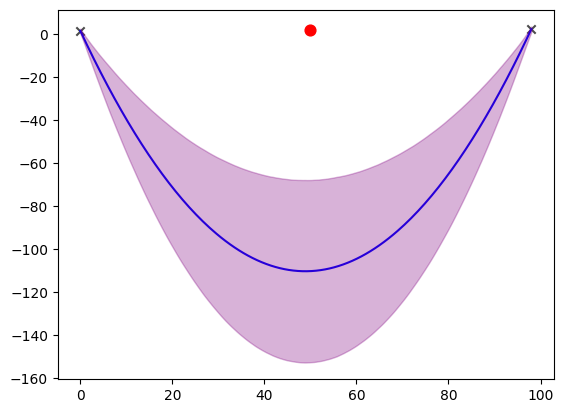

sample: 100%|██████████| 4000/4000 [00:05<00:00, 712.89it/s, 15 steps of size 1.13e-01. acc. prob=0.92] 



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
          a      0.00      0.00      0.00      0.00      0.01    567.00      1.00
          b     -0.31      0.15     -0.28     -0.53     -0.08    581.21      1.00
          c      2.69      2.11      2.75     -0.70      6.25   1139.27      1.00
k_length[0]      1.58      1.76      1.01      0.06      3.75   1251.85      1.00
    k_scale      5.46      7.71      2.88      0.07     13.74    743.03      1.00
      noise      6.28      9.85      2.85      0.06     15.22    580.44      1.00

Next suggested point: 36.0


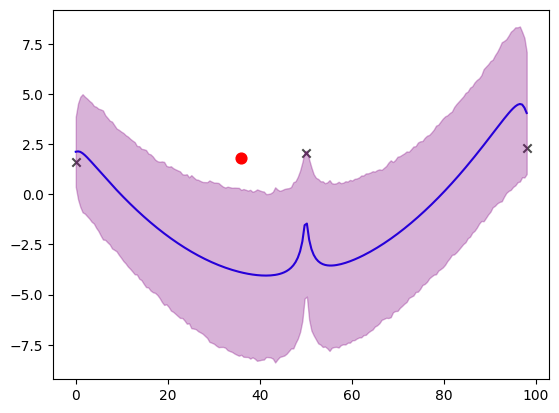

sample: 100%|██████████| 4000/4000 [00:05<00:00, 721.09it/s, 63 steps of size 1.34e-01. acc. prob=0.93] 



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
          a      0.00      0.00      0.00      0.00      0.00    652.99      1.00
          b     -0.23      0.11     -0.21     -0.38     -0.05    650.04      1.00
          c      3.39      1.90      3.42      0.40      6.33    934.29      1.00
k_length[0]      1.63      2.03      0.95      0.03      3.76   1196.28      1.00
    k_scale      4.60      7.06      2.43      0.04     10.34    744.78      1.00
      noise      4.17      5.92      2.11      0.04      9.75    776.98      1.00

Next suggested point: 95.0


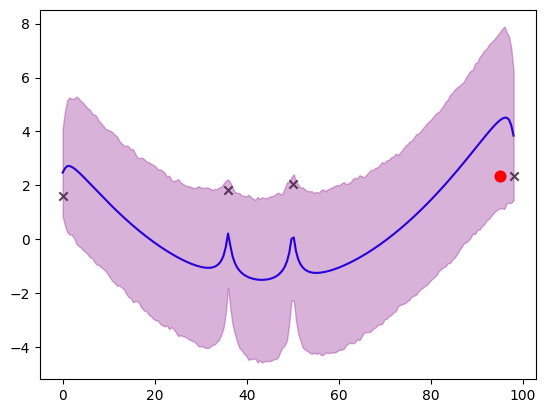

sample: 100%|██████████| 4000/4000 [00:05<00:00, 672.73it/s, 31 steps of size 1.08e-01. acc. prob=0.92] 



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
          a      0.00      0.00      0.00      0.00      0.00    542.02      1.00
          b     -0.21      0.10     -0.19     -0.36     -0.07    533.87      1.00
          c      3.35      1.73      3.38      0.63      6.15   1017.22      1.00
k_length[0]      2.30      3.07      1.20      0.05      5.44    952.17      1.00
    k_scale      3.70      4.82      2.14      0.06      8.17    713.68      1.00
      noise      2.87      4.02      1.58      0.05      6.59    722.27      1.00

Next suggested point: 43.0


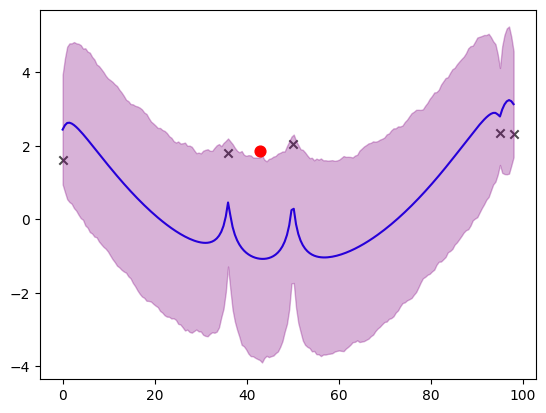

sample: 100%|██████████| 4000/4000 [00:06<00:00, 663.49it/s, 63 steps of size 1.01e-01. acc. prob=0.94] 



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
          a      0.00      0.00      0.00      0.00      0.00    526.55      1.00
          b     -0.17      0.08     -0.16     -0.28     -0.05    517.74      1.00
          c      3.52      1.53      3.54      1.04      6.00    876.84      1.00
k_length[0]      3.62      4.86      1.60      0.04      9.37    789.64      1.00
    k_scale      3.05      3.67      1.95      0.05      6.78    574.51      1.00
      noise      2.06      2.98      1.19      0.05      4.70    616.32      1.00

Next suggested point: 60.0


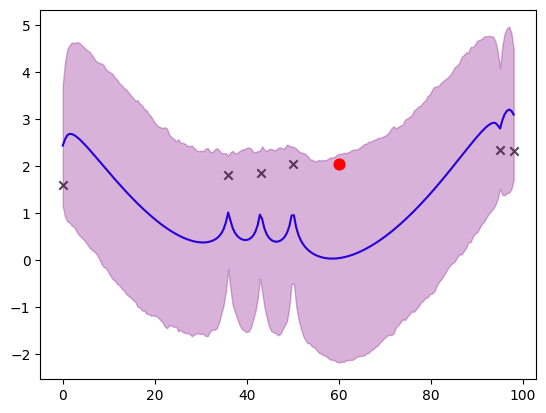

sample: 100%|██████████| 4000/4000 [00:06<00:00, 585.86it/s, 63 steps of size 1.11e-01. acc. prob=0.93]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
          a      0.00      0.00      0.00      0.00      0.00    474.16      1.00
          b     -0.15      0.07     -0.14     -0.26     -0.05    461.53      1.00
          c      3.43      1.50      3.38      1.09      5.99    763.58      1.00
k_length[0]      4.32      5.95      1.68      0.06     12.74    746.49      1.00
    k_scale      2.58      2.95      1.65      0.07      5.90    709.15      1.00
      noise      1.69      2.64      0.93      0.02      3.78    547.02      1.00

Next suggested point: 10.0


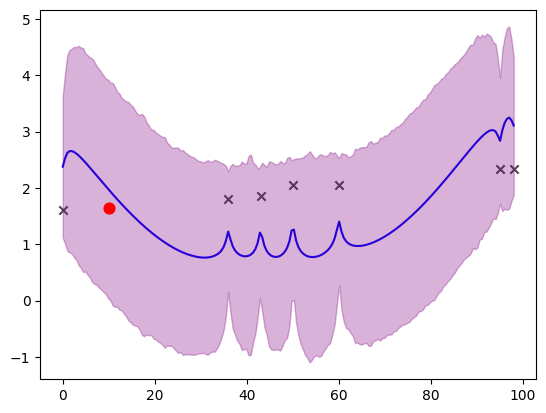

sample: 100%|██████████| 4000/4000 [00:09<00:00, 422.64it/s, 63 steps of size 9.13e-02. acc. prob=0.96] 



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
          a      0.00      0.00      0.00      0.00      0.00    495.11      1.00
          b     -0.13      0.06     -0.12     -0.23     -0.05    509.80      1.00
          c      3.15      1.24      3.11      1.23      5.22    874.17      1.01
k_length[0]      4.97      6.80      1.98      0.04     13.99    681.71      1.00
    k_scale      2.09      2.78      1.32      0.04      4.30    602.07      1.00
      noise      1.26      1.50      0.78      0.04      2.88    949.47      1.00

Next suggested point: 88.0


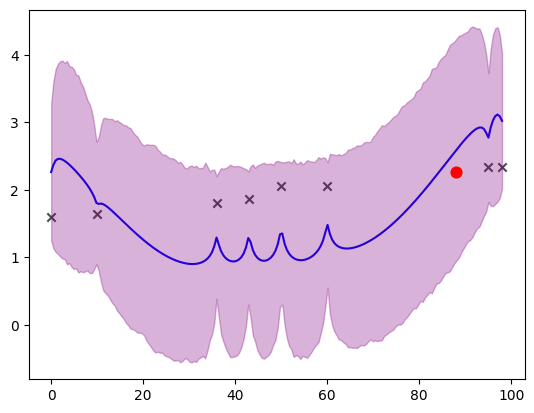

sample: 100%|██████████| 4000/4000 [00:08<00:00, 487.67it/s, 63 steps of size 1.17e-01. acc. prob=0.92] 



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
          a      0.00      0.00      0.00      0.00      0.00    353.19      1.00
          b     -0.12      0.06     -0.11     -0.21     -0.04    343.72      1.00
          c      3.06      1.19      3.02      1.01      4.83    647.67      1.00
k_length[0]      6.68      8.63      2.79      0.06     18.29    626.13      1.00
    k_scale      1.89      2.40      1.21      0.06      4.15    412.51      1.00
      noise      0.96      1.22      0.56      0.02      2.14    632.53      1.00

Next suggested point: 20.0


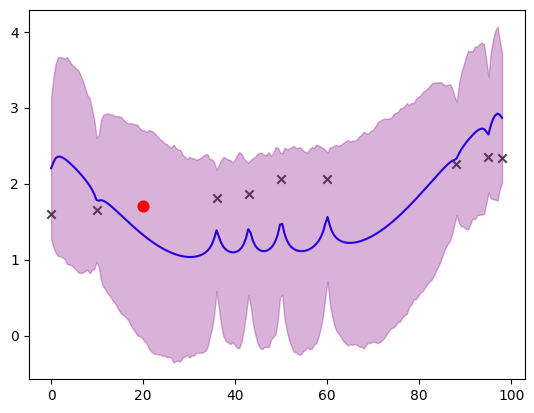

sample: 100%|██████████| 4000/4000 [00:08<00:00, 495.93it/s, 15 steps of size 1.19e-01. acc. prob=0.88]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
          a      0.00      0.00      0.00      0.00      0.00    374.98      1.00
          b     -0.12      0.05     -0.11     -0.20     -0.04    370.16      1.00
          c      2.98      1.13      2.90      1.37      4.91    660.58      1.00
k_length[0]      8.90     10.85      4.00      0.07     24.61    489.02      1.00
    k_scale      1.64      1.94      1.06      0.05      3.52    446.41      1.00
      noise      0.68      0.80      0.43      0.02      1.53    894.16      1.00

Next suggested point: 55.0


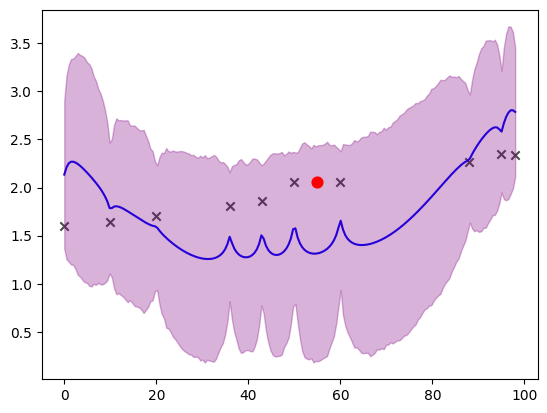

sample: 100%|██████████| 4000/4000 [00:08<00:00, 494.56it/s, 7 steps of size 1.10e-01. acc. prob=0.84] 



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
          a      0.00      0.00      0.00      0.00      0.00    368.46      1.01
          b     -0.11      0.06     -0.10     -0.19     -0.03    393.13      1.01
          c      2.71      1.25      2.76      0.48      4.53    580.31      1.00
k_length[0]     14.37     13.09     11.90      0.07     32.37    325.37      1.01
    k_scale      1.91      2.46      1.11      0.07      4.38    423.88      1.02
      noise      0.40      0.50      0.22      0.01      0.95    540.67      1.00

Next suggested point: 75.0


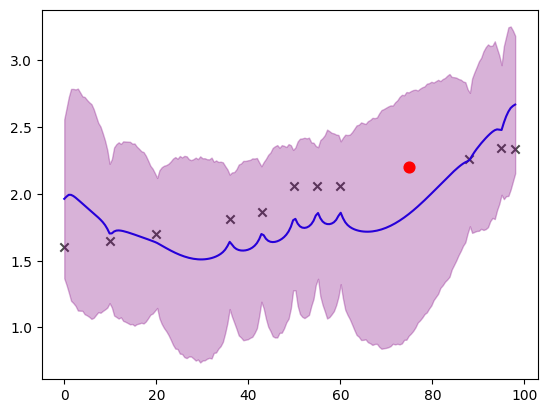

sample: 100%|██████████| 4000/4000 [00:07<00:00, 515.72it/s, 31 steps of size 1.21e-01. acc. prob=0.53]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
          a      0.00      0.00      0.00      0.00      0.00     10.66      1.00
          b     -0.07      0.05     -0.05     -0.15     -0.02     11.28      1.00
          c      2.36      1.01      2.25      1.15      4.27    349.12      1.00
k_length[0]     12.29     15.25      3.09      0.08     35.11     16.37      1.01
    k_scale      1.27      2.40      0.38      0.04      3.34     37.68      1.00
      noise      0.20      0.33      0.09      0.01      0.47    117.10      1.00

Next suggested point: 5.0


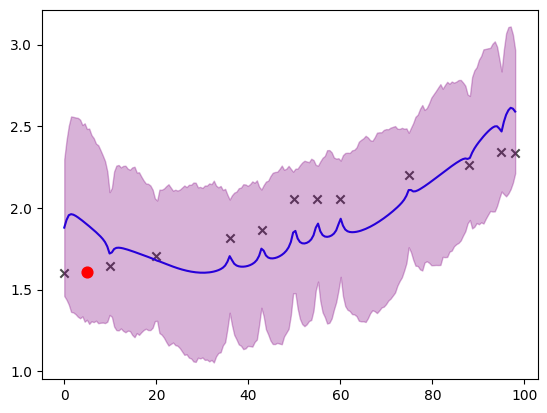

sample: 100%|██████████| 4000/4000 [00:07<00:00, 520.75it/s, 31 steps of size 1.26e-01. acc. prob=0.89]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
          a      0.00      0.00      0.00      0.00      0.00    326.99      1.01
          b     -0.11      0.06     -0.10     -0.18     -0.02    335.82      1.01
          c      2.26      1.36      2.30     -0.13      4.27    726.06      1.00
k_length[0]     26.44     14.97     25.10      0.22     45.85    381.89      1.00
    k_scale      2.30      2.82      1.42      0.09      5.11    550.67      1.00
      noise      0.14      0.18      0.08      0.01      0.31    502.42      1.00

Next suggested point: 30.0


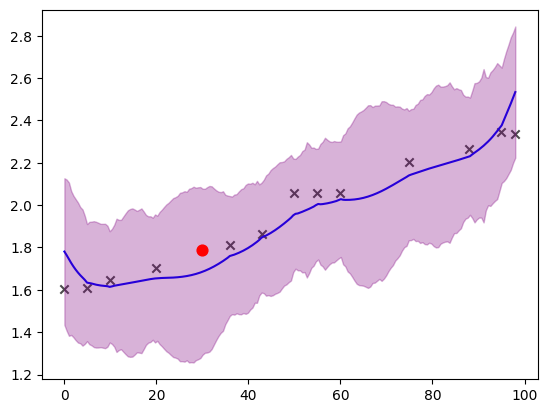

sample: 100%|██████████| 4000/4000 [00:06<00:00, 592.12it/s, 1 steps of size 1.68e-01. acc. prob=0.31] 



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
          a      0.00      0.00      0.00      0.00      0.00      5.09      1.55
          b     -0.06      0.04     -0.04     -0.12     -0.02      5.48      1.49
          c      2.22      0.82      2.28      1.11      3.42    355.06      1.00
k_length[0]     11.85     16.67      2.39      0.14     38.95      4.74      1.48
    k_scale      0.91      1.74      0.23      0.05      2.52     11.11      1.23
      noise      0.14      0.14      0.09      0.01      0.29     13.51      1.03

Next suggested point: 8.0


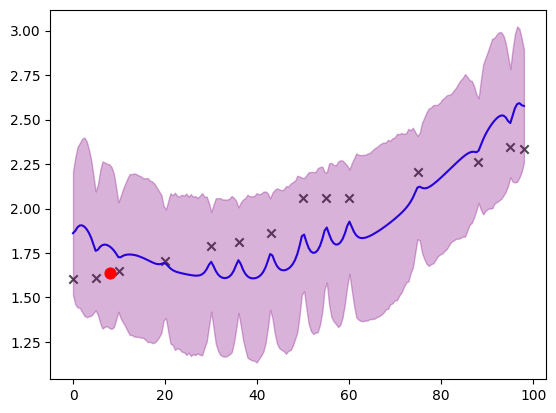

sample: 100%|██████████| 4000/4000 [00:07<00:00, 506.43it/s, 15 steps of size 1.73e-01. acc. prob=0.85]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
          a      0.00      0.00      0.00      0.00      0.00    414.90      1.00
          b     -0.10      0.05     -0.09     -0.16     -0.02    415.66      1.00
          c      1.95      1.40      2.07     -0.17      4.28    520.54      1.00
k_length[0]     35.50     15.74     33.13      9.11     57.88    560.51      1.01
    k_scale      2.47      2.91      1.61      0.16      5.15    410.32      1.00
      noise      0.05      0.07      0.03      0.00      0.11    715.47      1.00

Next suggested point: 65.0


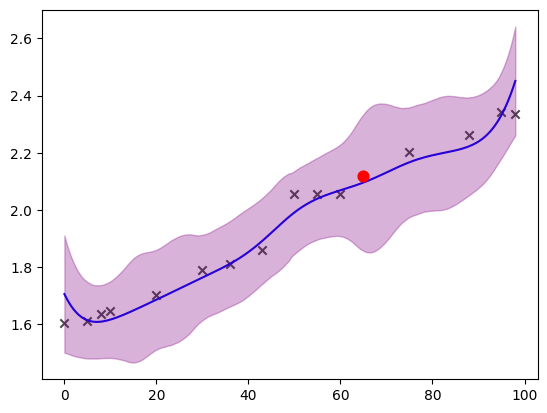

sample: 100%|██████████| 4000/4000 [00:07<00:00, 519.93it/s, 15 steps of size 1.96e-01. acc. prob=0.82]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
          a      0.00      0.00      0.00      0.00      0.00    557.23      1.00
          b     -0.09      0.04     -0.08     -0.15     -0.01    617.58      1.00
          c      1.79      1.34      1.83     -0.35      4.03    967.11      1.00
k_length[0]     39.76     15.55     37.35     16.60     65.08    662.87      1.00
    k_scale      2.35      2.68      1.51      0.13      5.04    664.65      1.00
      noise      0.03      0.03      0.02      0.00      0.07    914.11      1.00

Next suggested point: 83.0


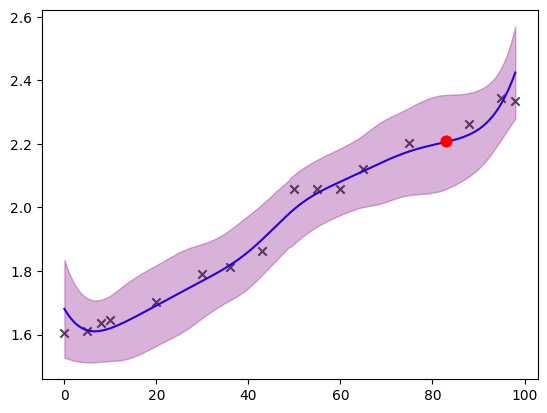

sample: 100%|██████████| 4000/4000 [00:08<00:00, 495.75it/s, 15 steps of size 1.66e-01. acc. prob=0.78]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
          a      0.00      0.00      0.00      0.00      0.00     40.83      1.04
          b     -0.07      0.05     -0.07     -0.14     -0.01     44.52      1.03
          c      1.80      1.23      1.88     -0.27      3.72    741.88      1.00
k_length[0]     37.58     20.02     37.19      6.35     63.66     17.44      1.11
    k_scale      2.00      2.62      1.24      0.05      4.47    117.21      1.02
      noise      0.03      0.03      0.02      0.00      0.06     99.04      1.01

Next suggested point: 25.0


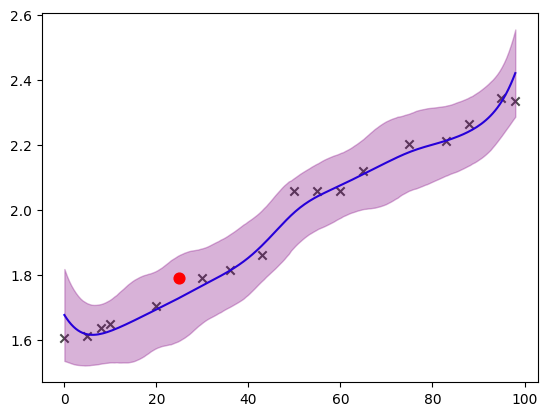

sample: 100%|██████████| 4000/4000 [00:09<00:00, 406.03it/s, 15 steps of size 1.55e-01. acc. prob=0.90]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
          a      0.00      0.00      0.00      0.00      0.00    417.23      1.00
          b     -0.08      0.05     -0.07     -0.14     -0.02    406.64      1.01
          c      1.57      1.39      1.72     -0.68      3.70    868.00      1.00
k_length[0]     44.99     17.05     43.13     17.37     69.54    517.00      1.01
    k_scale      2.46      3.18      1.52      0.08      5.34    425.56      1.00
      noise      0.02      0.01      0.01      0.00      0.03    971.19      1.00

Next suggested point: 0.5


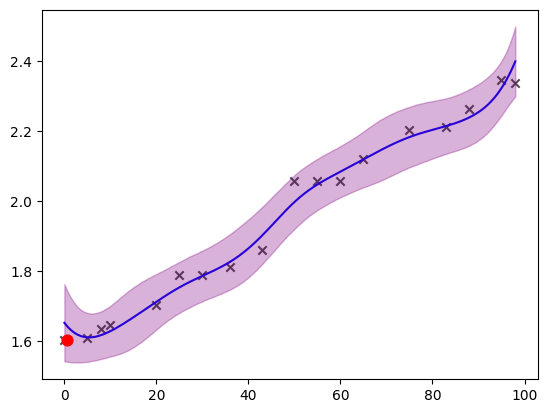

sample: 100%|██████████| 4000/4000 [00:08<00:00, 450.31it/s, 15 steps of size 2.09e-01. acc. prob=0.86]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
          a      0.00      0.00      0.00      0.00      0.00    664.83      1.00
          b     -0.08      0.04     -0.07     -0.14     -0.01    658.65      1.00
          c      1.57      1.29      1.67     -0.46      3.78   1061.02      1.00
k_length[0]     47.65     16.92     45.00     18.17     71.25    878.16      1.00
    k_scale      2.43      3.21      1.57      0.23      5.01    757.12      1.00
      noise      0.01      0.01      0.01      0.00      0.02    944.41      1.00

Next suggested point: 70


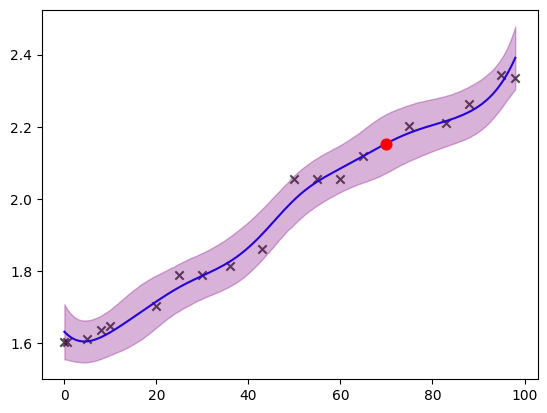

sample: 100%|██████████| 4000/4000 [00:08<00:00, 451.42it/s, 15 steps of size 1.77e-01. acc. prob=0.91]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
          a      0.00      0.00      0.00      0.00      0.00    542.40      1.00
          b     -0.08      0.04     -0.07     -0.14     -0.02    623.50      1.00
          c      1.49      1.33      1.57     -0.72      3.48    879.69      1.00
k_length[0]     49.65     17.39     47.31     20.14     73.20    786.26      1.00
    k_scale      2.45      3.03      1.63      0.14      5.20    709.27      1.00
      noise      0.01      0.01      0.01      0.00      0.02   1109.35      1.00

Next suggested point: 85


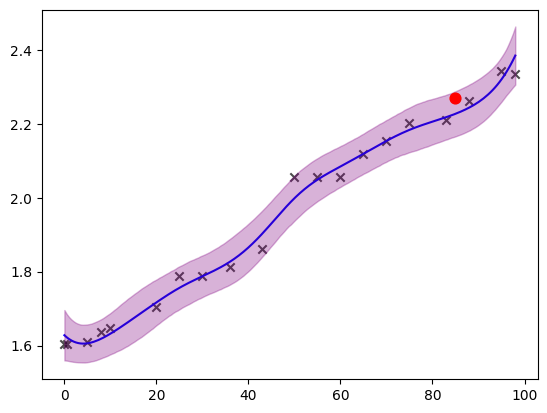

sample: 100%|██████████| 4000/4000 [00:09<00:00, 415.71it/s, 15 steps of size 1.90e-01. acc. prob=0.89]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
          a      0.00      0.00      0.00      0.00      0.00    735.54      1.00
          b     -0.07      0.04     -0.06     -0.12     -0.01    780.66      1.00
          c      1.49      1.23      1.55     -0.38      3.54   1112.69      1.00
k_length[0]     51.24     17.46     48.76     25.03     78.11    918.29      1.00
    k_scale      2.37      3.24      1.57      0.17      4.86    867.66      1.00
      noise      0.01      0.01      0.01      0.00      0.01    782.84      1.00

Next suggested point: 14


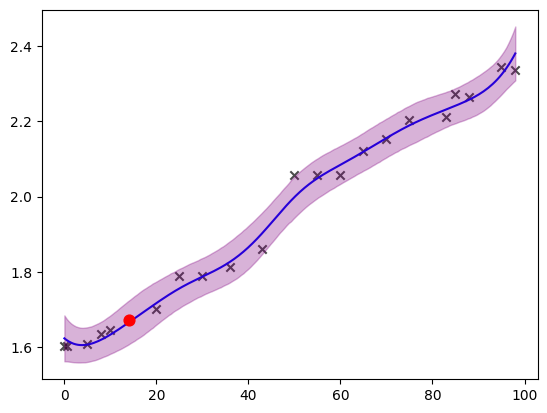

sample: 100%|██████████| 4000/4000 [00:09<00:00, 408.44it/s, 31 steps of size 1.77e-01. acc. prob=0.93]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
          a      0.00      0.00      0.00      0.00      0.00    565.91      1.00
          b     -0.07      0.04     -0.06     -0.13     -0.01    568.09      1.00
          c      1.42      1.35      1.54     -0.68      3.56   1050.12      1.00
k_length[0]     52.76     17.44     50.89     25.71     81.29    756.05      1.01
    k_scale      2.38      2.53      1.67      0.14      4.82    647.78      1.00
      noise      0.01      0.00      0.00      0.00      0.01   1037.12      1.00

Next suggested point: 40


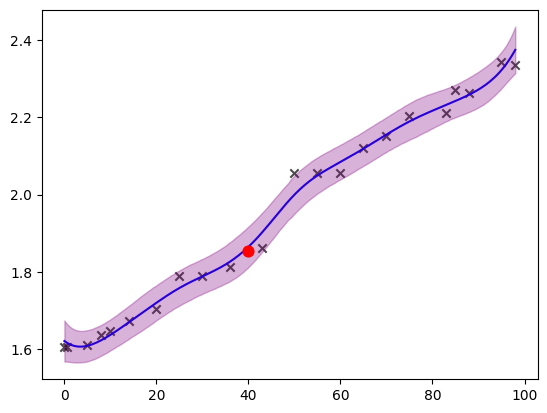

sample: 100%|██████████| 4000/4000 [00:14<00:00, 268.31it/s, 15 steps of size 1.70e-01. acc. prob=0.93]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
          a      0.00      0.00      0.00      0.00      0.00    626.76      1.00
          b     -0.07      0.04     -0.06     -0.12     -0.01    644.20      1.00
          c      1.36      1.35      1.48     -0.84      3.43   1066.94      1.00
k_length[0]     54.22     17.69     51.47     25.53     81.09    778.80      1.01
    k_scale      2.43      2.71      1.64      0.11      5.13    746.68      1.00
      noise      0.00      0.00      0.00      0.00      0.01   1009.98      1.00

Next suggested point: 92


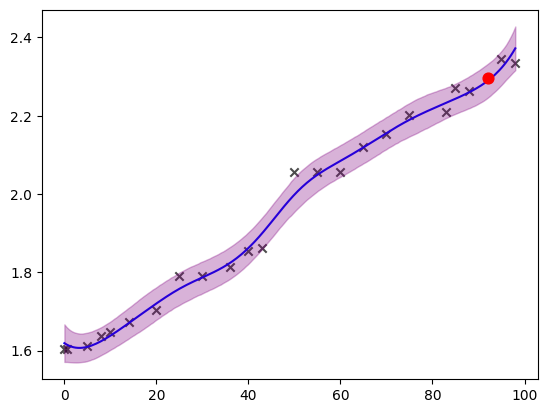

sample: 100%|██████████| 4000/4000 [00:09<00:00, 437.90it/s, 15 steps of size 2.08e-01. acc. prob=0.89]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
          a      0.00      0.00      0.00      0.00      0.00    654.97      1.00
          b     -0.06      0.04     -0.06     -0.12     -0.02    657.75      1.00
          c      1.36      1.22      1.46     -0.67      3.31   1222.65      1.00
k_length[0]     55.05     18.22     52.25     25.97     82.89    921.56      1.00
    k_scale      2.32      3.01      1.56      0.14      4.80    788.96      1.00
      noise      0.00      0.00      0.00      0.00      0.01   1111.77      1.00

Next suggested point: 80


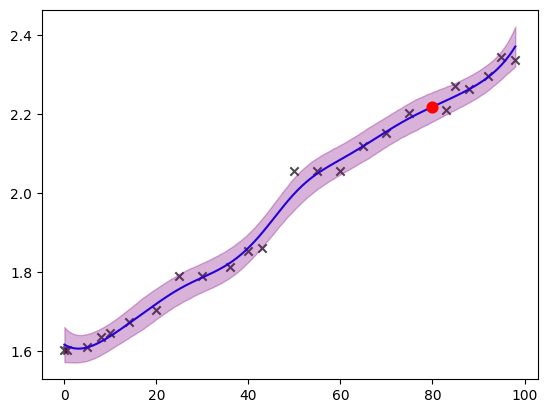

sample: 100%|██████████| 4000/4000 [00:10<00:00, 370.10it/s, 31 steps of size 1.84e-01. acc. prob=0.93]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
          a      0.00      0.00      0.00      0.00      0.00    801.36      1.00
          b     -0.06      0.03     -0.06     -0.12     -0.02    801.19      1.00
          c      1.33      1.29      1.44     -0.79      3.34   1047.73      1.00
k_length[0]     57.46     18.20     55.09     27.44     83.81    860.95      1.01
    k_scale      2.41      2.85      1.59      0.16      5.05    900.23      1.00
      noise      0.00      0.00      0.00      0.00      0.01   1460.78      1.00

Next suggested point: 45


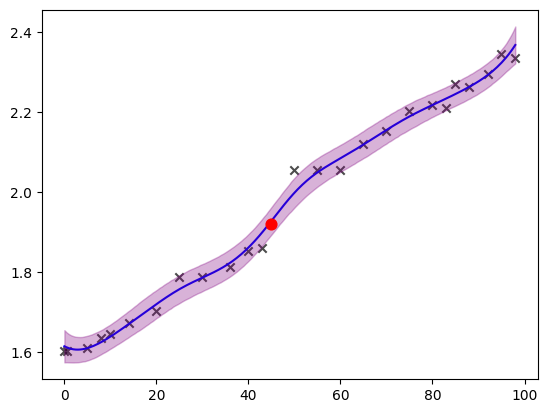

sample: 100%|██████████| 4000/4000 [00:10<00:00, 374.31it/s, 31 steps of size 1.69e-01. acc. prob=0.94]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
          a      0.00      0.00      0.00      0.00      0.00    792.59      1.00
          b     -0.06      0.03     -0.06     -0.11     -0.01    740.82      1.00
          c      1.24      1.31      1.39     -0.82      3.24    899.36      1.00
k_length[0]     58.53     19.29     55.76     30.87     90.09    674.96      1.00
    k_scale      2.43      2.80      1.56      0.11      5.49    770.31      1.00
      noise      0.00      0.00      0.00      0.00      0.00   1126.36      1.00

Next suggested point: 27


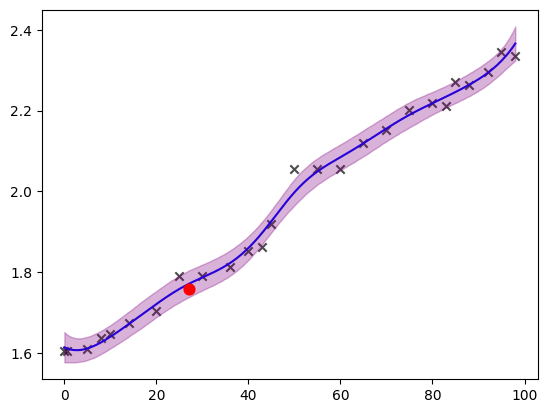

sample: 100%|██████████| 4000/4000 [00:11<00:00, 355.84it/s, 15 steps of size 1.80e-01. acc. prob=0.94]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
          a      0.00      0.00      0.00      0.00      0.00    766.33      1.00
          b     -0.06      0.03     -0.06     -0.10     -0.01    761.13      1.00
          c      1.31      1.26      1.42     -0.81      3.25   1313.90      1.00
k_length[0]     58.88     18.73     56.44     30.12     87.25    862.08      1.00
    k_scale      2.33      2.62      1.55      0.14      4.88    841.45      1.00
      noise      0.00      0.00      0.00      0.00      0.00   1191.91      1.00

Next suggested point: 48


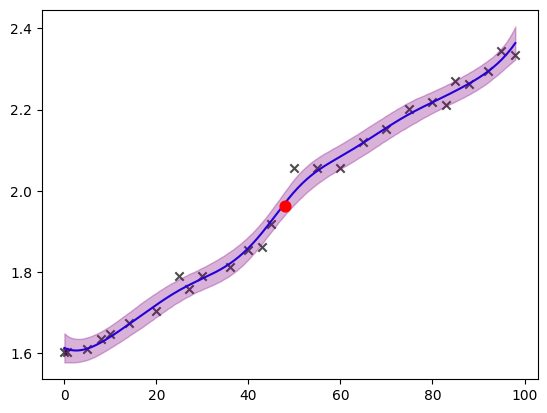

sample: 100%|██████████| 4000/4000 [00:10<00:00, 399.57it/s, 31 steps of size 1.54e-01. acc. prob=0.96]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
          a      0.00      0.00      0.00      0.00      0.00    796.98      1.00
          b     -0.06      0.03     -0.05     -0.11     -0.01    828.02      1.00
          c      1.21      1.31      1.33     -0.95      3.16    925.98      1.00
k_length[0]     60.48     19.42     57.76     31.05     91.38    824.21      1.00
    k_scale      2.39      2.57      1.54      0.11      5.49    749.82      1.00
      noise      0.00      0.00      0.00      0.00      0.00   1044.07      1.00

Next suggested point: 35


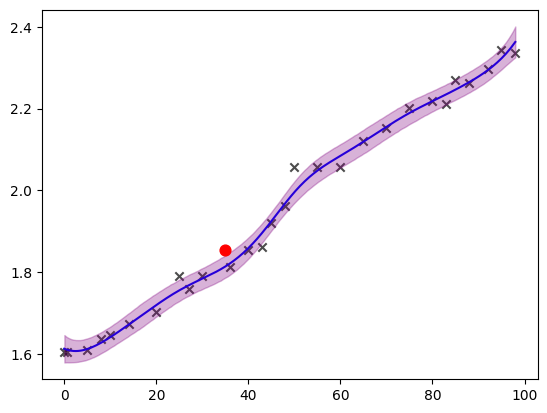

sample: 100%|██████████| 4000/4000 [00:10<00:00, 367.86it/s, 31 steps of size 1.82e-01. acc. prob=0.93]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
          a      0.00      0.00      0.00      0.00      0.00    721.87      1.00
          b     -0.06      0.03     -0.05     -0.10     -0.01    746.50      1.00
          c      1.24      1.27      1.41     -0.83      3.17   1073.72      1.00
k_length[0]     61.60     19.67     59.38     29.83     89.52    699.55      1.01
    k_scale      2.25      2.65      1.50      0.10      4.74    779.85      1.00
      noise      0.00      0.00      0.00      0.00      0.00   1197.59      1.00

Next suggested point: 15


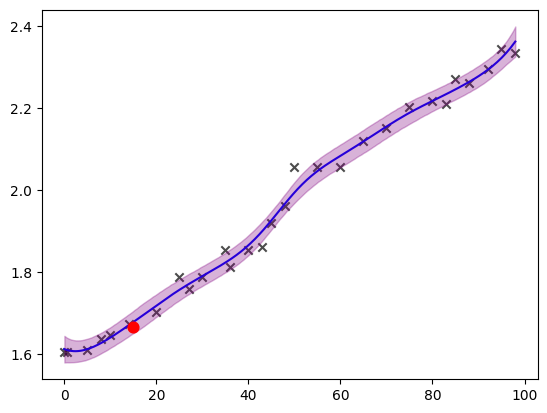

sample: 100%|██████████| 4000/4000 [00:11<00:00, 356.88it/s, 15 steps of size 2.31e-01. acc. prob=0.85]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
          a      0.00      0.00      0.00      0.00      0.00    282.88      1.00
          b     -0.06      0.03     -0.05     -0.10     -0.01    311.17      1.01
          c      1.28      1.25      1.44     -0.84      3.09    930.81      1.00
k_length[0]     61.09     21.11     58.07     30.10     98.80    156.09      1.01
    k_scale      2.20      2.65      1.38      0.05      4.97    680.91      1.00
      noise      0.00      0.00      0.00      0.00      0.00   1049.06      1.00

Next suggested point: 90


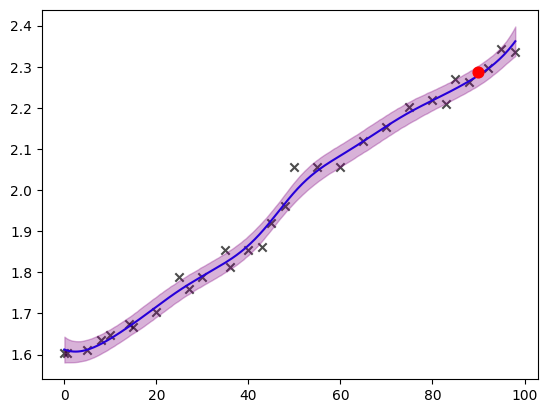

sample: 100%|██████████| 4000/4000 [00:12<00:00, 313.29it/s, 31 steps of size 2.02e-01. acc. prob=0.93]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
          a      0.00      0.00      0.00      0.00      0.00    755.26      1.00
          b     -0.06      0.03     -0.05     -0.10     -0.01    745.06      1.00
          c      1.21      1.26      1.32     -0.73      3.26   1087.61      1.00
k_length[0]     63.98     20.41     60.69     33.34     97.17    845.82      1.00
    k_scale      2.32      2.68      1.53      0.13      5.02    907.64      1.00
      noise      0.00      0.00      0.00      0.00      0.00   1406.38      1.00

Next suggested point: 2


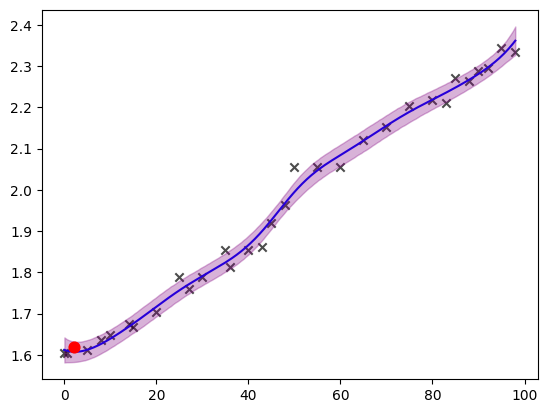

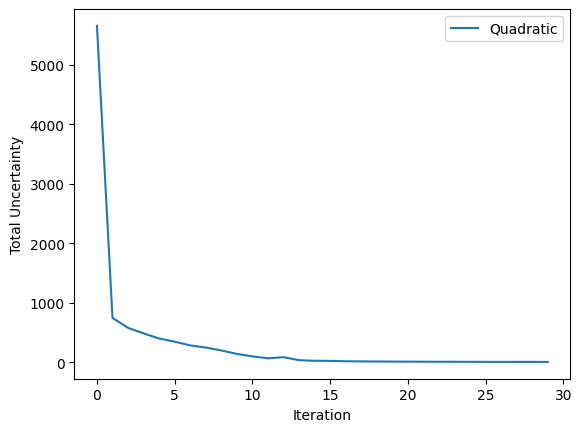

In [ ]:
# All necessary imports go here, including the ones you provided

def optimize_GP_and_collect_uncertainty(mean_fn, mean_fn_prior, X_init, y_init, steps=30):
    X_train = X_init.copy()
    y_train = y_init.copy()

    # Store all uncertainties
    all_uncertainty = []

    for _ in range(steps):
        # Get random number generator keys
        rng_key, rng_key_predict = gpax.utils.get_keys()

        # Initialize structured GP model
        sgp_model = gpax.ExactGP(1, kernel='Matern', mean_fn=mean_fn, mean_fn_prior=mean_fn_prior)

        # Run MCMC to obtain posterior samples
        sgp_model.fit(rng_key, X_train, y_train, jitter=1e-4)

        # Generate predictions for plotting
        X_new = np.linspace(0, 98, 200).reshape(-1, 1)
        y_mean, y_samples = sgp_model.predict_in_batches(rng_key_predict, X_new, noiseless=True, jitter=1e-4)

        # Add the uncertainty of this step to the list
        this_uncertainty = y_samples.std(axis=(0,1)).sum()
        all_uncertainty.append(this_uncertainty)

        # Use Expected Improvement as the acquisition function to find the next composition to explore
        X_unmeasured = np.array([[x] for x in compositions if x not in X_train.flatten()])
        acquisition_fn = acquisition.UE(rng_key, sgp_model, X_unmeasured, noiseless=False, jitter=1e-4)
        next_sample = X_unmeasured[np.argmax(acquisition_fn)]

        # Get the true bandgap for the suggested composition
        y_next = bandgaps[compositions.index(next_sample[0])]
        # Print the next suggested point
        print(f"Next suggested point: {next_sample[0]}")
         # Plot the results
        _, ax = plt.subplots(dpi=100)
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.scatter(X_train, y_train, marker='x', c='k', zorder=1, alpha=0.7)
        ax.plot(X_new, y_mean, lw=1.5, zorder=1, c='b')
        ax.fill_between(X_new.squeeze(), y_mean - y_samples.std(axis=(0,1)), y_mean + y_samples.std(axis=(0,1)),
                        color='purple', alpha=0.3)
        ax.scatter(next_sample, y_next, s=60, c='r')
        plt.show()

        # Update the training data
        X_train = np.vstack([X_train, next_sample])
        y_train = np.append(y_train, y_next)

    return all_uncertainty

# Given initial points
X_init = np.array([[0], [98]])
y_init = np.array([bandgaps[0], bandgaps[-1]])

# Collect uncertainties for each model
models = [

    ("Quadratic", quadratic, quadratic_prior)

]
#("Quadratic", quadratic, quadratic_prior)
all_model_uncertainties = {}

for name, mean_fn, mean_fn_prior in models:
    print(f"Optimizing for {name} model...")
    all_model_uncertainties[name] = optimize_GP_and_collect_uncertainty(mean_fn, mean_fn_prior, X_init, y_init)

# Plot the uncertainties for each model
plt.figure(dpi=100)
for name, uncertainties in all_model_uncertainties.items():
    plt.plot(uncertainties, label=name)

plt.xlabel("Iteration")
plt.ylabel("Total Uncertainty")
plt.legend()
plt.show()


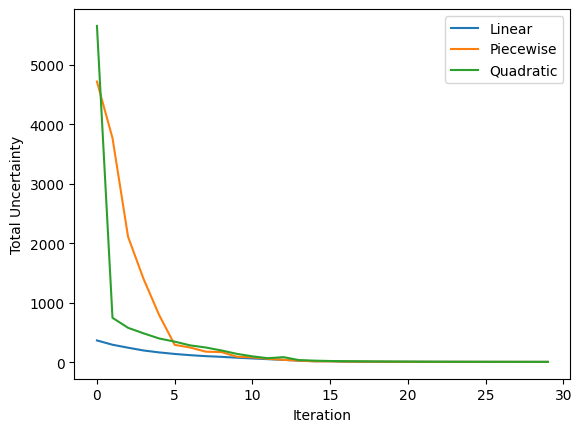

In [ ]:
# Plot the uncertainties for each model
plt.figure(dpi=100)
for name, uncertainties in all_model_uncertainties.items():
    plt.plot(uncertainties, label=name)

plt.xlabel("Iteration")
plt.ylabel("Total Uncertainty")
plt.legend()
plt.show()


In [ ]:
uncertainty_dict

{95.0: Array(235.11494493, dtype=float64),
 36.0: Array(225.81696362, dtype=float64),
 92.0: Array(183.38220147, dtype=float64),
 90.0: Array(162.9202951, dtype=float64),
 85.0: Array(160.94915833, dtype=float64),
 65.0: Array(148.78088626, dtype=float64),
 75.0: Array(124.66085542, dtype=float64),
 50.0: Array(46.21365067, dtype=float64),
 20.0: Array(16.13967614, dtype=float64),
 10.0: Array(8.88016778, dtype=float64),
 27.0: Array(5.58606173, dtype=float64),
 55.0: Array(5.24734284, dtype=float64),
 0.5: Array(5.02404502, dtype=float64),
 45: Array(4.35951874, dtype=float64),
 70: Array(4.31747707, dtype=float64),
 6: Array(4.04400186, dtype=float64),
 40: Array(3.74740133, dtype=float64),
 15: Array(3.66936179, dtype=float64),
 80: Array(3.48499207, dtype=float64),
 60: Array(3.34901306, dtype=float64),
 48: Array(3.43423491, dtype=float64),
 30: Array(3.32700578, dtype=float64),
 35: Array(3.20339487, dtype=float64),
 12: Array(3.17251796, dtype=float64),
 2: Array(3.10088205, dty

In [ ]:
c_sGP_uncertainties = list(uncertainty_dict.values())

In [ ]:
c_sGP_uncertainties

[Array(235.11494493, dtype=float64),
 Array(225.81696362, dtype=float64),
 Array(183.38220147, dtype=float64),
 Array(162.9202951, dtype=float64),
 Array(160.94915833, dtype=float64),
 Array(148.78088626, dtype=float64),
 Array(124.66085542, dtype=float64),
 Array(46.21365067, dtype=float64),
 Array(16.13967614, dtype=float64),
 Array(8.88016778, dtype=float64),
 Array(5.58606173, dtype=float64),
 Array(5.24734284, dtype=float64),
 Array(5.02404502, dtype=float64),
 Array(4.35951874, dtype=float64),
 Array(4.31747707, dtype=float64),
 Array(4.04400186, dtype=float64),
 Array(3.74740133, dtype=float64),
 Array(3.66936179, dtype=float64),
 Array(3.48499207, dtype=float64),
 Array(3.34901306, dtype=float64),
 Array(3.43423491, dtype=float64),
 Array(3.32700578, dtype=float64),
 Array(3.20339487, dtype=float64),
 Array(3.17251796, dtype=float64),
 Array(3.10088205, dtype=float64),
 Array(3.06255033, dtype=float64),
 Array(3.06394728, dtype=float64),
 Array(3.15115728, dtype=float64),
 Arra

In [ ]:
# Convert numpy arrays to standard python list
c_sGP_uncertainties_list = [float(item) for item in c_sGP_uncertainties]

# Add the list to the dictionary
all_model_uncertainties["C-sGP"] = c_sGP_uncertainties_list



In [ ]:
all_model_uncertainties

{'Linear': [Array(365.36221058, dtype=float64),
  Array(293.02966904, dtype=float64),
  Array(243.28691126, dtype=float64),
  Array(196.3418521, dtype=float64),
  Array(163.95735917, dtype=float64),
  Array(138.14062357, dtype=float64),
  Array(117.56314909, dtype=float64),
  Array(101.15382806, dtype=float64),
  Array(89.43916348, dtype=float64),
  Array(74.94967664, dtype=float64),
  Array(62.45290067, dtype=float64),
  Array(50.12368524, dtype=float64),
  Array(38.2536084, dtype=float64),
  Array(25.7793726, dtype=float64),
  Array(16.38681231, dtype=float64),
  Array(16.07747129, dtype=float64),
  Array(7.94308808, dtype=float64),
  Array(6.59484882, dtype=float64),
  Array(5.88058724, dtype=float64),
  Array(5.19885946, dtype=float64),
  Array(5.75472857, dtype=float64),
  Array(5.34654767, dtype=float64),
  Array(4.98290954, dtype=float64),
  Array(4.71113487, dtype=float64),
  Array(4.42290673, dtype=float64),
  Array(4.25725018, dtype=float64),
  Array(4.26114059, dtype=float64

In [ ]:
key_mapping = {
    "Linear": "sGP Linear",
    "Piecewise": "sGP Piecewise",
    "Quadratic": "sGP Quadratic"
}
updated_model_uncertainties = {key_mapping.get(k, k): v for k, v in all_model_uncertainties.items()}
all_model_uncertainties = updated_model_uncertainties


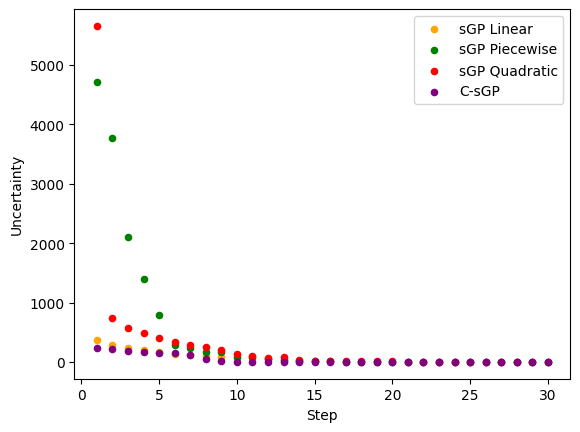

In [ ]:


# Color mapping for each model
color_map = {
    "sGP Linear": "orange",
    "sGP Piecewise": "green",
    "sGP Quadratic": "red",
    "C-sGP": "purple"
}

plt.figure(dpi=100)

for name, uncertainties in all_model_uncertainties.items():
    x_values = range(1, len(uncertainties) + 1)  # Generate x-values for iterations
    plt.scatter(x_values, uncertainties, label=name, s=20, color=color_map[name])  # Scatter plot with markers

plt.xlabel("Step")
plt.ylabel("Uncertainty")
plt.legend()
plt.show()


In [ ]:
c_sGP_uncertainties = list(uncertainty_dict.values())

In [ ]:
c_sGP_uncertainties

[Array(235.11494493, dtype=float64),
 Array(225.81696362, dtype=float64),
 Array(183.38220147, dtype=float64),
 Array(162.9202951, dtype=float64),
 Array(160.94915833, dtype=float64),
 Array(148.78088626, dtype=float64),
 Array(124.66085542, dtype=float64),
 Array(46.21365067, dtype=float64),
 Array(16.13967614, dtype=float64),
 Array(8.88016778, dtype=float64),
 Array(5.58606173, dtype=float64),
 Array(5.24734284, dtype=float64),
 Array(5.02404502, dtype=float64),
 Array(4.35951874, dtype=float64),
 Array(4.31747707, dtype=float64),
 Array(4.04400186, dtype=float64),
 Array(3.74740133, dtype=float64),
 Array(3.66936179, dtype=float64),
 Array(3.48499207, dtype=float64),
 Array(3.34901306, dtype=float64),
 Array(3.43423491, dtype=float64),
 Array(3.32700578, dtype=float64),
 Array(3.20339487, dtype=float64),
 Array(3.17251796, dtype=float64),
 Array(3.10088205, dtype=float64),
 Array(3.06255033, dtype=float64),
 Array(3.06394728, dtype=float64),
 Array(3.15115728, dtype=float64),
 Arra

In [ ]:
uncertainty_dict

In [ ]:
##############---create dir, list, etc to save each step information---###############
# create a dir to save plots of each step, then these images will be used to make movie at the end
savedir = "/content/video_image_c_sGP/"
if os.path.exists(savedir) == False:
  os.mkdir(savedir)

# create lists to save uncertainty, mse, k_length, k_scale, and model parameters at each step
all_uncertainty_csGP = []
all_mse_csGP = []
all_k_length_csGP = []
all_k_scale_csGP = []

model = piecewise_quadratic #None
model_prior = piecewise_quadratic_prior #None

##############---prepare data---###########
# prepare training data
X = jnp.linspace(0.0, 2, NUM_INIT_POINTS)
idx = jnp.asarray([0, NUM_INIT_POINTS-1])#set seed points to two extreme conditions
indx = idx.tolist()

# select model here
y_all = ymdata[:, None]
Y = jnp.asarray([y_all[0][0], y_all[199][0]])

# initialize training data
(X_train, y_train, X_test, y_test,
 indices_train, indices_test) = init_training_data_exp(X, Y, y_all, list_of_indices = indx)


# Inside the Bayesian Optimization Loop
for s in range(exploration_steps):
    print("#######---Exploration step {}---#######".format(s))

    # Compute acquisition function
    if model is None or model_prior is None:  # Select GP or sGP
        acq, (y_pred, y_sampled), paras_ = step_GP(X_train, y_train, X_test)
    else:
        acq, (y_pred, y_sampled), paras_ = step_sGP(X_train, y_train, X_test, model, model_prior)

    # Get the next point to evaluate
    next_point = acq.argmax()
    X_next = X_test[next_point]


    # Plot
    f, ax1 = plt.subplots(figsize=(6, 4), dpi=100)
    f.suptitle("Exploration step {}".format(s))
    ax1.set_xlabel("Concentration")
    ax1.set_ylabel("$Bandgap$ ($E_g$)")
    ax1.scatter(X_train, y_train, marker='x', c='k', s=100, linewidths=2, edgecolors='k', zorder=3)  # Noisy observations
    ax1.plot(X_test, y_pred, lw=1.5, zorder=2, c='b')  # Posterior mean
    ax1.scatter(X, y_all, c="chocolate", zorder=1)  # Ground truth
    ax1.scatter(X_test[next_point], y_pred[next_point], s=60, c='r', zorder=3)  # Next point to measure
    ax1.fill_between(X_test.squeeze(), y_pred - y_sampled.std(axis=(0, 1)), y_pred + y_sampled.std(axis=(0, 1)),
                     color='goldenrod', alpha=0.5)  # Model uncertainty
    ax1.set_ylim(-1.5, 1.5)
    plt.show()
    f.savefig(os.path.join(savedir, '{}.png'.format(s)))

    # add the uncertainty of this step to the list
    this_uncertainty = y_sampled.std(axis=(0,1)).sum()
    all_uncertainty_csGP.append(this_uncertainty)
    # add the mse of this step to the list
    this_mse = mean_squared_error(y_test,y_pred)
    all_mse_csGP.append(this_mse)
    # add the k_length of this step to the list
    this_k_length = paras_['k_length'].mean()
    all_k_length_csGP.append(this_k_length)
    # add the k_scale of this step to the list
    this_k_scale = paras_['k_scale'].mean()
    all_k_scale_csGP.append(this_k_scale)


    y_new = jnp.asarray(y_test[next_point])  # Get next bandgap
    y_test = jnp.delete(y_test, next_point)  # Update bandgap data set
    print("next bandgap: \n", y_new)
    # Update training data
    X_train, y_train, X_test = update_datapoints_exp(next_point, X_train, y_train, X_test, y_new)


# plot the evoltution of uncerstainty
f1, ax = plt.subplots(figsize = (6, 4), dpi=100)
f1.suptitle("Uncertainty Evolution")
ax.set_xlabel("Step")
ax.set_ylabel("Uncertainty")
ax.scatter(np.arange(exploration_steps), all_uncertainty_csGP, s = 60, c='r')

# plot the evolution of MSE
f2, ax = plt.subplots(figsize = (6, 4), dpi=100)
f2.suptitle("MSE Evolution")
ax.set_xlabel("Step")
ax.set_ylabel("MSE")
ax.scatter(np.arange(exploration_steps), all_mse_csGP, s = 60, c='r')

# plot the evolution of k_length
f3, ax = plt.subplots(figsize = (6, 4), dpi=100)
f3.suptitle("k_length Evolution")
ax.set_xlabel("Step")
ax.set_ylabel("k_length")
ax.scatter(np.arange(exploration_steps), all_k_length_csGP, s = 60, c='r')

# plot the evolution of k_scale
f4, ax = plt.subplots(figsize = (6, 4), dpi=100)
f4.suptitle("k_scale Evolution")
ax.set_xlabel("Step")
ax.set_ylabel("k_scale")
ax.scatter(np.arange(exploration_steps), all_k_scale_csGP, s = 60, c='r')
